# Calculating J

In [17]:
import torch

# Some parts of the following are vibe-coded with Gemini; fixed by Kevin Lim and Zihan Guo

# Use float64 for maximum precision with exponential terms
torch.set_default_dtype(torch.float64)

def calculate_J(R1, R2, S0, theta):

    # Slicing the parameters
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    nus1 = torch.cat([nus1, torch.tensor([S0])])
    nus2 = torch.cat([torch.tensor([S0]), nus2])


    # Calculate Unit Base Coefficients (Setting lam1 = 1, lam2 = 1)

    # Left Side
    c_v1_unit = []
    dist0 = nus1[1] - nus1[0]
    c_v1_unit.append((-torch.exp(-dist0/sigs1[0]), torch.exp(dist0/sigs1[0])))

    # recursively calculating c^1
    for j in range(R1 - 1):
        P = c_v1_unit[j][0] + c_v1_unit[j][1]
        S = (1/sigs1[j]) * (-c_v1_unit[j][0] + c_v1_unit[j][1])
        dist = nus1[j+2] - nus1[j+1]
        c_v1_unit.append((0.5 * (P - sigs1[j+1]*S) * torch.exp(-dist/sigs1[j+1]),
                          0.5 * (P + sigs1[j+1]*S) * torch.exp(dist/sigs1[j+1])))

    # Right Side
    c_v2_unit = [None] * R2
    dist_u = nus2[-1] - nus2[-2]
    c_v2_unit[-1] = ((torch.exp(dist_u/sigs2[-1]), -torch.exp(-dist_u/sigs2[-1])))

    # recursively calculating c^2
    for j in range(R2 - 1, 0, -1):
        P = c_v2_unit[j][0] + c_v2_unit[j][1]
        S = (1/sigs2[j]) * (-c_v2_unit[j][0] + c_v2_unit[j][1])
        dist = nus2[j] - nus2[j-1]
        c_v2_unit[j-1] = (0.5 * (P - sigs2[j-1]*S) * torch.exp(dist/sigs2[j-1]),
                          0.5 * (P + sigs2[j-1]*S) * torch.exp(-dist/sigs2[j-1]))

    # Unscaled left-side value at S0
    v1 = c_v1_unit[-1][0] + c_v1_unit[-1][1]

    # Unscaled right-side value at S0
    v2 = c_v2_unit[0][0] + c_v2_unit[0][1]

    # Unscaled left-side derivative at S0
    Dk_v1 = (1/sigs1[-1]) * (-c_v1_unit[-1][0] + c_v1_unit[-1][1])

    # Unscaled right-side derivative at S0
    Dk_v2 = (1/sigs2[0]) * (-c_v2_unit[0][0] + c_v2_unit[0][1])

    # Values for lambda1 and lambda2
    lam1 = v2 / (Dk_v1 * v2 - v1 * Dk_v2)
    lam2 = v1 / (Dk_v1 * v2 - v1 * Dk_v2)

    c_v1 = [(c1 * lam1, c2 * lam1) for (c1, c2) in c_v1_unit]
    c_v2 = [(c1 * lam2, c2 * lam2) for (c1, c2) in c_v2_unit]

    jumps = []
    weights = []
    weights2 = []

    def eval_V_K(K_val):
        if K_val <= S0:
            index = torch.bucketize(K_val, nus1, right=False) - 1
            index = torch.clamp(index, 0, R1 - 1).item()
            dist  = nus1[index + 1] - K_val
            V_K   = (c_v1[index][0] * torch.exp( dist / sigs1[index]) +
                     c_v1[index][1] * torch.exp(-dist / sigs1[index]))
            return V_K + (S0 - K_val)
        else:
            index = torch.bucketize(K_val, nus2, right=False) - 1
            index = torch.clamp(index, 0, R2 - 1).item()
            dist  = K_val - nus2[index]
            V_K   = (c_v2[index][0] * torch.exp(-dist / sigs2[index]) +
                     c_v2[index][1] * torch.exp( dist / sigs2[index]))
            return V_K

    # Left Side Jumps
    for j in range(R1 - 1):
        v_left = (1/sigs1[j]**2) * (c_v1[j][0] + c_v1[j][1])
        dist = nus1[j+2] - nus1[j+1]
        v_right = (1/sigs1[j+1]**2) * (c_v1[j+1][0]*torch.exp(dist/sigs1[j+1]) +
                                             c_v1[j+1][1]*torch.exp(-dist/sigs1[j+1]))
        jumps.append(v_right - v_left)
        with torch.no_grad():
            w = eval_V_K(nus1[j+1].detach()).detach()
            weights.append(torch.clamp(w, min=1e-4))
            w2 = nus1[j] / S0
            weights2.append(w2)

    # Jump at S0
    v1_S0 = (1/sigs1[-1]**2) * (c_v1[-1][0] + c_v1[-1][1])
    v2_S0 = (1/sigs2[0]**2) * (c_v2[0][0] + c_v2[0][1])

    jumps.append(v2_S0 - v1_S0)
    with torch.no_grad():
        w_S0 = eval_V_K(torch.tensor(S0, dtype=theta.dtype)).detach()
        weights.append(torch.clamp(w_S0, min=1e-4))
        weights2.append(1)

    # Right Side Jumps
    for j in range(R2 - 1):
        v_right = (1/sigs2[j+1]**2) * (c_v2[j+1][0] + c_v2[j+1][1])
        dist = nus2[j+1] - nus2[j]
        v_left = (1/sigs2[j]**2) * (c_v2[j][0]*torch.exp(-dist/sigs2[j]) +
                                             c_v2[j][1]*torch.exp(dist/sigs2[j]))
        jumps.append(v_right - v_left)
        with torch.no_grad():
            w = eval_V_K(nus2[j+1].detach()).detach()
            weights.append(torch.clamp(w, min=1e-4))
            w2 = nus2[j+1] / S0
            weights2.append(w2)

    jumps_t   = torch.stack(jumps)
    weights_t = torch.tensor(weights, dtype=theta.dtype)
    weights2_t = torch.tensor(weights2, dtype=theta.dtype)
    j = torch.sum(torch.stack(jumps) ** 2)
    j_weighted = torch.sum((jumps_t**2 / weights_t) * weights2_t)

    # for i in range(R1):
    #     C_K.append(c_v1[i][0] + c_v1[i][1] + S0 - nus1[i])

    # C_K.append(c_v1[-1][0] * torch.exp((nus1[-1] - nus1[-2]) / sigs1[-1]) + c_v1[-1][1] * torch.exp(-(nus1[-1] - nus1[-2]) / sigs1[-1]) + S0 - nus1[i])

    # for i in range(R2):
    #     C_K.append(c_v2[i][0] + c_v2[i][1])

    # C_K = torch.stack(C_K)

    # return j, lam1, lam2, C_K
    # print("c_v1", c_v1)
    # print("c_v2",c_v2)
    return j_weighted, lam1, lam2, c_v1, c_v2

In [18]:
def C_K(K, R1, R2, S0, theta, c_v1, c_v2):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    if isinstance(K, (int, float)):
        K_val = K
    else:
        K_val = K.item()

    if K_val <= S0:
        S0_tensor = torch.tensor([S0], dtype=nus1.dtype, device=nus1.device)
        nus1_full = torch.cat([nus1, S0_tensor])

        # side='left' equivalent in torch is right=False
        index = torch.bucketize(torch.tensor(K_val, device=nus1.device), nus1_full, right=False) - 1
        index = torch.clamp(index, 0, R1 - 1).item()

        # Distance measured from the right-hand node of the interval: nus1_full[index + 1]
        dist = nus1_full[index + 1] - K_val

        # Match original exponent assignments exactly
        # V_K = c_v1[index][0] * torch.exp(dist / sigs1[index]) + c_v1[index][1] * torch.exp(-dist / sigs1[index])
        V_K = c_v1[index][0] * torch.exp(dist / (sigs1[index])) + c_v1[index][1] * torch.exp(-dist / (sigs1[index]))
        # print("V_K", V_K)
        intrinsic_value = S0 - K_val
        # print("intrinsic_value", intrinsic_value)
        return V_K + intrinsic_value

    else:
        S0_tensor = torch.tensor([S0], dtype=nus2.dtype, device=nus2.device)
        nus2_full = torch.cat([S0_tensor, nus2])

        index = torch.bucketize(torch.tensor(K_val, device=nus2.device), nus2_full, right=False) - 1
        index = torch.clamp(index, 0, R2 - 1).item()

        # Distance measured from the left-hand node of the interval: nus2_full[index]
        dist = K_val - nus2_full[index]

        # Match original exponent assignments exactly: negative exponent first, positive second
        # V_K = c_v2[index][0] * torch.exp(-dist / sigs2[index]) + c_v2[index][1] * torch.exp(dist / sigs2[index])
        V_K = c_v2[index][0] * torch.exp(-dist / (sigs2[index])) + c_v2[index][1] * torch.exp(dist / (sigs2[index]))
        return V_K

def generate_call_prices(market_strikes, R1, R2, S0, theta, c_v1, c_v2):

    calculated_prices = []

    for K in market_strikes:
        price = C_K(K, R1, R2, S0, theta, c_v1, c_v2)
        calculated_prices.append(price)

    return torch.stack(calculated_prices)

In [19]:
def C2_K(K, R1, R2, S0, theta, c_v1, c_v2):
    """
    Calculates the exact second analytical derivative C''(K) at strike K
    """
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    if isinstance(K, (int, float)):
        K_val = K
    else:
        K_val = K.item()

    if K_val <= S0:
        S0_tensor = torch.tensor([S0], dtype=nus1.dtype, device=nus1.device)
        nus1_full = torch.cat([nus1, S0_tensor])

        index = torch.bucketize(torch.tensor(K_val, device=nus1.device), nus1_full, right=False) - 1
        index = torch.clamp(index, 0, R1 - 1).item()

        dist = nus1_full[index + 1] - K_val

        # Clean analytical second derivative scaled by (1 / sigma^2)
        return (1.0 / (sigs1[index] ** 2)) * (c_v1[index][0] * torch.exp(dist / sigs1[index]) + c_v1[index][1] * torch.exp(-dist / sigs1[index]))

    else:
        S0_tensor = torch.tensor([S0], dtype=nus2.dtype, device=nus2.device)
        nus2_full = torch.cat([S0_tensor, nus2])

        index = torch.bucketize(torch.tensor(K_val, device=nus2.device), nus2_full, right=False) - 1
        index = torch.clamp(index, 0, R2 - 1).item()

        dist = K_val - nus2_full[index]

        # Clean analytical second derivative scaled by (1 / sigma^2)
        return (1.0 / (sigs2[index] ** 2)) * (c_v2[index][0] * torch.exp(-dist / sigs2[index]) + c_v2[index][1] * torch.exp(dist / sigs2[index]))


def generate_C2K(market_strikes, R1, R2, S0, theta, c_v1, c_v2):
    """
    Loops through an array of market strikes and evaluates the continuous
    second derivative C2_K for each item to output a stacked tracking vector.
    """
    calculated_second_derivatives = []

    for K in market_strikes:
        c2_value = C2_K(K, R1, R2, S0, theta, c_v1, c_v2)
        calculated_second_derivatives.append(c2_value)

    return torch.stack(calculated_second_derivatives)

# Built-in Line Search with torch.optim.LBFGS (constrained)

**Log barrier method**

$\min_{\theta} L(\theta) = J(\theta) + \mu \sum_{i=1}^{R_1 + R_2 + 1} \left[ -\ln\left(C(K_i) - \text{Bid}_i\right) - \ln\left(\text{Ask}_i - C(K_i)\right) \right]$

Minimize $f(x)$ s.t. $g_i(x) \le 0, \forall i = 1, \dots, m$

Modified objective function: $f(x) - \mu \sum_{i=1}^m \log(-g_i(x))$

In [20]:
def obtain_nus(R1, R2, theta):
    nus1 = theta[0 : R1]
    nus2 = theta[2 * R1 : 2 * R1 + R2]
    return nus1, nus2

def obtain_sigs(R1, R2, theta):
    sigs1 = theta[R1 : 2 * R1]
    sigs2 = theta[2 * R1 + R2 : 2 * R1 + 2 * R2]
    return sigs1, sigs2

# def C_K(R1, R2, S0, theta):
#     _, _, _, C_K = calculate_J(R1, R2, S0, theta)
#     return C_K

# nus do not include S0
def obtain_theta(R1, R2, S0, sigs1, sigs2, nus1, nus2):
    theta = torch.cat([nus1, sigs1, nus2, sigs2])
    return theta

In [21]:
def generate_bid_ask_matrix(R1, R2, S0, theta, eps_bid_vector, eps_ask_vector):

    nus1, nus2 = obtain_nus(R1, R2, theta)

    S0_tensor = torch.tensor([S0], dtype=nus1.dtype, device=nus1.device)
    strikes = torch.cat([nus1, S0_tensor, nus2])

    # (N x 3) matrix
    bid_ask_matrix = torch.zeros((R1 + R2 + 1, 3), dtype=theta.dtype, device=theta.device)

    bid_ask_matrix[:, 0] = strikes
    model_prices = C_K(R1, R2, S0, theta)
    bid_ask_matrix[:, 1] = torch.clamp(model_prices - eps_bid_vector, min=0.0)
    bid_ask_matrix[:, 2] = model_prices + eps_ask_vector
    return bid_ask_matrix

In [22]:
def check_constraints(R1, R2, S0, sigs1, sigs2, nus1, nus2, bid_ask, market_strikes):

    # 1. Strictly increasing knots and boundary conditions relative to S0
    increasing_nus1 = torch.all(torch.diff(nus1) > 0) and (nus1[-1] <= S0)
    increasing_nus2 = torch.all(torch.diff(nus2) > 0) and (nus2[0] >= S0)

    # 2. Strictly positive sigmas
    positive_sigs1 = torch.all(sigs1 > 0)
    positive_sigs2 = torch.all(sigs2 > 0)

    # (N x 3) bid_ask matrix
    strikes = bid_ask[:, 0]
    market_bids = bid_ask[:, 1]
    market_asks = bid_ask[:, 2]

    theta = obtain_theta(R1, R2, S0, sigs1, sigs2, nus1, nus2)

    _, _, _, c_v1, c_v2 = calculate_J(R1, R2, S0, theta)

    model_prices = generate_call_prices(market_strikes, R1, R2, S0, theta, c_v1, c_v2)

    # 3. Bid and ask checks
    bid_check = torch.all(model_prices >= market_bids)
    ask_check = torch.all(model_prices <= market_asks)
    bid_ask_check = bid_check and ask_check

    is_valid = increasing_nus1 and increasing_nus2 and positive_sigs1 and positive_sigs2 and bid_ask_check

    return is_valid.item() if hasattr(is_valid, 'item') else bool(is_valid)

In [23]:
import pandas as pd
import torch
import numpy as np

def load_market_data(quotes_path, arb_free_path):
    quotes_df = pd.read_csv(quotes_path, header=None)

    strikes = quotes_df.iloc[:, 0].values
    market_asks = quotes_df.iloc[:, 1].values
    market_bids = quotes_df.iloc[:, 2].values

    bid_ask_data = np.column_stack((strikes, market_bids, market_asks))
    bid_ask_tensor = torch.tensor(bid_ask_data, dtype=torch.float32)

    arb_df = pd.read_csv(arb_free_path, header=None)
    market_prices = torch.tensor(arb_df.iloc[:, 0].values, dtype=torch.float32)
    arb_strikes = torch.tensor(arb_df.iloc[:, 1].values, dtype=torch.float32)

    return bid_ask_tensor, market_prices, arb_strikes

# Augmented Lagrangian

In [24]:
# def gradient_guided_sample(theta_ref, R1, R2, S0, bid_ask, loss_fn,
#                              generate_call_prices, n_samples=100,
#                              step_size=0.01, noise_scale=0.1, tol=1e-6):
#     market_strikes = bid_ask[:, 0]
#     market_bids    = bid_ask[:, 1]
#     market_asks    = bid_ask[:, 2]

#     best = {"theta": None, "J": float('inf')}

#     for _ in range(n_samples):
#         # Step 1: gradient descent on violation to find feasible point
#         theta_w = theta_ref.detach().clone().requires_grad_(True)
#         for _ in range(20):  # few steps of violation reduction
#             J, _, _, c1, c2 = loss_fn(R1, R2, S0, theta_w)
#             C_K = generate_call_prices(market_strikes, R1, R2, S0, theta_w, c1, c2)
#             viol = torch.sum(torch.clamp(market_bids - C_K, min=0)**2) + \
#                    torch.sum(torch.clamp(C_K - market_asks, min=0)**2)
#             if viol.item() < 1e-12:
#                 break
#             viol.backward()
#             with torch.no_grad():
#                 theta_w = (theta_w - step_size * theta_w.grad).detach().requires_grad_(True)

#         # Step 2: add small noise around this feasible point
#         with torch.no_grad():
#             noise = torch.randn_like(theta_w) * noise_scale
#             theta_cand = theta_w.detach() + noise

#             J_c, _, _, c1_c, c2_c = loss_fn(R1, R2, S0, theta_cand)
#             C_K_c = generate_call_prices(market_strikes, R1, R2, S0, theta_cand, c1_c, c2_c)
#             mv = max(torch.clamp(market_bids - C_K_c, min=0).max().item(),
#                      torch.clamp(C_K_c - market_asks, min=0).max().item())

#             if mv < tol and not torch.isnan(J_c) and J_c.item() < best["J"]:
#                 best["J"]     = J_c.item()
#                 best["theta"] = theta_cand.clone()
#                 print(f"    [guided] feasible: J={best['J']:.10f}")

#     return best["theta"]

# def latin_hypercube_sample(theta_ref, R1, R2, S0, bid_ask, loss_fn,
#                             generate_call_prices, n_samples=200,
#                             radius=1.0, tol=1e-6):
#     from scipy.stats import qmc
#     market_strikes = bid_ask[:, 0]
#     market_bids    = bid_ask[:, 1]
#     market_asks    = bid_ask[:, 2]
#     dim = theta_ref.shape[0]

#     # LHS gives uniform coverage in [0,1]^dim, map to [-radius, radius]^dim
#     sampler   = qmc.LatinHypercube(d=dim)
#     lhs_draws = sampler.random(n=n_samples)           # shape (n_samples, dim)
#     lhs_draws = (lhs_draws * 2 - 1) * radius          # map to [-r, r]

#     best = {"theta": None, "J": float('inf')}
#     with torch.no_grad():
#         best["J"] = loss_fn(R1, R2, S0, theta_ref)[0].item()

#     for i in range(n_samples):
#         with torch.no_grad():
#             noise      = torch.tensor(lhs_draws[i], dtype=theta_ref.dtype)
#             theta_cand = theta_ref.detach() + noise

#             try:
#                 J_c, _, _, c1, c2 = loss_fn(R1, R2, S0, theta_cand)
#                 C_K_c = generate_call_prices(
#                     market_strikes, R1, R2, S0, theta_cand, c1, c2)

#                 if torch.isnan(J_c):
#                     continue

#                 mv = max(torch.clamp(market_bids - C_K_c, min=0).max().item(),
#                          torch.clamp(C_K_c - market_asks, min=0).max().item())

#                 if mv < tol and J_c.item() < best["J"]:
#                     best["J"]     = J_c.item()
#                     best["theta"] = theta_cand.clone()
#                     print(f"  [LHS {i+1}] J={best['J']:.10f}")
#             except Exception:
#                 continue

#     return best["theta"]

# def scaled_neighborhood_sample(theta_ref, R1, R2, S0, bid_ask, loss_fn,
#                                 generate_call_prices, n_samples=200,
#                                 nus_radius=5.0, sigs_radius=2.0, tol=1e-6):
#     market_strikes = bid_ask[:, 0]
#     market_bids    = bid_ask[:, 1]
#     market_asks    = bid_ask[:, 2]

#     # Build per-parameter noise scale
#     noise_scale        = torch.ones_like(theta_ref)
#     noise_scale[:R1]              = nus_radius    # nus1
#     noise_scale[R1:2*R1]          = sigs_radius   # sigs1
#     noise_scale[2*R1:2*R1+R2]     = nus_radius    # nus2
#     noise_scale[2*R1+R2:]         = sigs_radius   # sigs2

#     best = {"theta": None, "J": float('inf')}

#     with torch.no_grad():
#         J_ref = loss_fn(R1, R2, S0, theta_ref)[0].item()
#         best["J"] = J_ref

#     for i in range(n_samples):
#         with torch.no_grad():
#             noise      = torch.randn_like(theta_ref) * noise_scale
#             theta_cand = theta_ref.detach() + noise

#             try:
#                 J_c, _, _, c1, c2 = loss_fn(R1, R2, S0, theta_cand)
#                 C_K_c = generate_call_prices(
#                     market_strikes, R1, R2, S0, theta_cand, c1, c2)

#                 if torch.isnan(J_c) or torch.isinf(J_c):
#                     continue

#                 mv = max(torch.clamp(market_bids - C_K_c, min=0).max().item(),
#                          torch.clamp(C_K_c - market_asks, min=0).max().item())

#                 if mv < tol and J_c.item() < best["J"]:
#                     best["J"]     = J_c.item()
#                     best["theta"] = theta_cand.clone()
#                     print(f"  [scaled sample {i+1}] J={best['J']:.10f}")
#             except Exception:
#                 continue

#     return best["theta"]

In [25]:
def sample_feasible_neighborhood(theta_ref, R1, R2, S0, bid_ask, loss_fn,
                                  generate_call_prices,
                                  n_samples=200, radius=50.0,
                                  tol_constraint=1e-6):
    """
    Randomly sample neighbors of theta_ref at varying radii.
    Returns the best feasible theta found (lowest J), or None.
    """
    market_strikes = bid_ask[:, 0]
    market_bids    = bid_ask[:, 1]
    market_asks    = bid_ask[:, 2]

    # sample from multivariate normal (Gaussian) distribution
    # centered at theta_ref

    with torch.no_grad():
        J_ref, _, _, c1, c2 = loss_fn(R1, R2, S0, theta_ref)
        J_ref = J_ref.item()

    best = {"theta": None, "J": J_ref}
    radii = [radius, radius * 0.1, radius * 0.01, radius * 0.001, radius * 10]  # multi-scale search

    for r in radii:
        feasible_count = 0
        for i in range(n_samples // len(radii)):
            with torch.no_grad():
                noise     = torch.randn_like(theta_ref) * r
                theta_cand = theta_ref.detach() + noise

                try:
                    J_cand, _, _, c1_c, c2_c = loss_fn(R1, R2, S0, theta_cand)
                    C_K_cand = generate_call_prices(
                        market_strikes, R1, R2, S0, theta_cand, c1_c, c2_c)

                    if torch.isnan(J_cand) or torch.isinf(J_cand):
                        continue

                    # bid and ask constraints
                    # max_viol > 0 when constraints are not met
                    max_viol = max(
                        torch.clamp(market_bids - C_K_cand, min=0).max().item(),
                        torch.clamp(C_K_cand - market_asks, min=0).max().item()
                    )

                    if max_viol < tol_constraint:
                        feasible_count += 1
                        if J_cand.item() < best["J"]:
                            best["J"]     = J_cand.item()
                            best["theta"] = theta_cand.clone()

                except Exception:
                    continue

        print(f"  [radius={r:.3f}] feasible: {feasible_count}/{n_samples // len(radii)} "
              f"| best_J so far: {best['J']:.12f}")

    if best["theta"] is not None:
        print(f"  Neighborhood search: improved J from {J_ref:.12f} to {best['J']:.12f}")
    else:
        print(f"  Neighborhood search: no improvement found (kept J={J_ref:.12f})")

    return best["theta"]  # None if no improvement


def is_stuck_at_boundary(J_change, max_viol, tol_J, tol_constraint):
    # true or false:
    """Stuck = J barely moved AND we're right at (or just inside) the boundary."""
    near_boundary = max_viol < tol_constraint * 100  # within 100x of constraint tol
    j_stalled = J_change < tol_J * 1000
    return near_boundary and j_stalled


def find_feasible_perturbation(theta, R1, R2, S0, bid_ask, loss_fn,
                                generate_call_prices,
                                n_attempts=50, radius=1e-2):
    """
    Search for a perturbation direction that:
    1. Keeps theta feasible
    2. Reduces J (or at least doesn't increase it much)
    Returns the best feasible perturbed theta found, or None.
    """
    market_strikes = bid_ask[:, 0]
    market_bids    = bid_ask[:, 1]
    market_asks    = bid_ask[:, 2]

    with torch.no_grad():
        # Evaluate current J to use as baseline for comparison
        J_curr, _, _, c1, c2 = loss_fn(R1, R2, S0, theta)
        C_K_curr = generate_call_prices(market_strikes, R1, R2, S0, theta, c1, c2)
        J_curr = J_curr.item()

    best_theta = None
    best_J     = J_curr

    # Compute gradient direction (the direction that hits the wall) to bias perturbations away from it
    # (we already know gradient direction hits the wall)
    # We compute gradient of augmented objective (J + large * violations)
    # This tells us which direction pushes C_K against the bid/ask boundaries
    theta_g = theta.clone().detach().requires_grad_(True)
    J_g, _, _, c1_g, c2_g = loss_fn(R1, R2, S0, theta_g)
    C_K_g = generate_call_prices(market_strikes, R1, R2, S0, theta_g, c1_g, c2_g)
    bid_viol = torch.clamp(market_bids - C_K_g, min=0.0)
    ask_viol = torch.clamp(C_K_g - market_asks, min=0.0)
    # 1e3 weight makes violations dominate — gradient points toward feasibility
    augmented = J_g + 1e3 * (torch.sum(bid_viol**2) + torch.sum(ask_viol**2))
    augmented.backward()
    # Normalize to get a unit direction vector
    grad_dir = theta_g.grad.clone()
    grad_dir = grad_dir / (grad_dir.norm() + 1e-12)

    for attempt in range(n_attempts):
        with torch.no_grad():
            # Random direction orthogonal to gradient (tangent to constraint boundary)
            # Draw random noise in full parameter space
            noise = torch.randn_like(theta)

            # Gram-Schmidt orthogonalization
            # Remove the component of noise along grad_dir:
            #   noise_perp = noise - (noise · grad_dir) * grad_dir
            # This makes noise_perp exactly perpendicular to grad_dir,
            # so moving in this direction stays tangent to the constraint boundary
            # Remove component along gradient direction (Gram-Schmidt)
            noise = noise - torch.dot(noise, grad_dir) * grad_dir
            noise = noise / (noise.norm() + 1e-12) # renormalize to unit length

            # Mix: mostly tangential, small random component for exploration
            # Shrink radius every 10 attempts if nothing found — zooms in
            scale = radius * (0.5 ** (attempt // 10))  # shrink radius every 10 tries
            direction = noise * scale

            # Evaluate candidate
            theta_candidate = theta.detach() + direction

            # Check feasibility
            J_cand, _, _, c1_c, c2_c = loss_fn(R1, R2, S0, theta_candidate)
            C_K_cand = generate_call_prices(market_strikes, R1, R2, S0,
                                             theta_candidate, c1_c, c2_c)

            max_viol = max(
                torch.clamp(market_bids - C_K_cand, min=0).max().item(),
                torch.clamp(C_K_cand - market_asks, min=0).max().item()
            )

            # Accept if feasible and within 1% of current best
            # (1% slack allows slightly uphill moves to escape saddle points)
            if max_viol < 1e-6 and J_cand.item() < best_J * 1.01:  # allow 1% slack
                best_J     = J_cand.item()
                best_theta = theta_candidate.clone()
                print(f"    [perturb {attempt+1:03d}] feasible seed found: J={best_J:.10f}")

    return best_theta

In [26]:
def block_coordinate_step(theta, lam_bid, lam_ask, rho,
                           R1, R2, S0, bid_ask, loss_fn,
                           generate_call_prices, slices):
    """
    Optimize each parameter block independently while freezing others.
    Cycles through nus1 → sigs1 → nus2 → sigs2.
    """
    market_bids    = bid_ask[:, 1]
    market_asks    = bid_ask[:, 2]
    market_strikes = bid_ask[:, 0]

    # Work on a detached copy — we write blocks back one at a time
    theta_work = theta.detach().clone()

    for group_name, sl in slices.items():
      # Extract this block as a fresh leaf tensor (only this block has grad)
        block = theta_work[sl].clone().requires_grad_(True)

        def make_closure(b, s):
            def closure():
                # Reconstruct full theta with this block active
                parts = [
                    theta_work[:s.start].detach(), # frozen: before this block
                    b,  # active: only this block differentiates
                    theta_work[s.stop:].detach() # frozen: after this block
                ]
                theta_full = torch.cat(parts)

                J, _, _, c_v1, c_v2 = loss_fn(R1, R2, S0, theta_full)
                C_K = generate_call_prices(
                    market_strikes, R1, R2, S0, theta_full, c_v1, c_v2)

                if torch.isnan(J) or torch.isinf(J):
                    return torch.tensor(1e9, dtype=theta_full.dtype,
                                        requires_grad=True)

                bid_viol = torch.clamp(market_bids - C_K, min=0.0)
                ask_viol = torch.clamp(C_K - market_asks, min=0.0)
                lag      = torch.dot(lam_bid, bid_viol) + \
                           torch.dot(lam_ask, ask_viol)
                penalty  = (rho / 2) * (torch.sum(bid_viol**2) +
                                        torch.sum(ask_viol**2))

                L = J + lag + penalty # gradient flows only through b (the active block)
                L.backward()
                return L
            return closure

        opt = torch.optim.LBFGS([block], max_iter=20,
                                  line_search_fn="strong_wolfe",
                                  tolerance_grad=1e-12,
                                  tolerance_change=1e-12)
        opt.step(make_closure(block, sl))

        # Write optimized block back
        with torch.no_grad():
            theta_work[sl] = block.detach()

        print(f"    [coord:{group_name}] done")

    return theta_work.requires_grad_(True)

In [27]:
def augmented_lagrangian_step(theta, lam_bid, lam_ask, rho, R1, R2, S0,
                               bid_ask, loss_fn, generate_call_prices,
                               lbfgs_max_iter=100):

    """
    One inner L-BFGS minimization of the augmented Lagrangian objective:
        L_aug = J + lam_bid·bid_viol + lam_ask·ask_viol
                  + (rho/2)*(||bid_viol||² + ||ask_viol||²)
    J         = smoothness objective (minimize jumps in C'')
    lag_term  = Lagrange multiplier term (linear in violations)
    penalty   = quadratic penalty (grows violations costly)
    After the inner solve, multipliers are updated via dual ascent:
        lam_bid ← max(0, lam_bid + rho * bid_violation)
        lam_ask ← max(0, lam_ask + rho * ask_violation)
    This pushes the next inner solve harder toward feasibility.
    """

    market_bids    = bid_ask[:, 1]
    market_asks    = bid_ask[:, 2]
    market_strikes = bid_ask[:, 0]

    # Ensure theta is a differentiable leaf tensor for L-BFGS
    if not theta.requires_grad:
        theta = theta.detach().requires_grad_(True)
    # L-BFGS with strong Wolfe line search for reliable convergence
    optimizer = torch.optim.LBFGS(
        [theta], max_iter=lbfgs_max_iter,
        line_search_fn="strong_wolfe",
        tolerance_grad=1e-13,
        tolerance_change=1e-13
    )

    def closure():
        # Required by L-BFGS: zero gradients, compute loss, call backward
        optimizer.zero_grad()
        J, _, _, c_v1, c_v2 = loss_fn(R1, R2, S0, theta)
        C_K = generate_call_prices(market_strikes, R1, R2, S0, theta, c_v1, c_v2)

        # If J is NaN/Inf (e.g. sigs went negative), return a
        # differentiable constant that has zero gradient — L-BFGS
        # will see no improvement and stop safely
        if torch.isnan(J) or torch.isinf(J):
            return torch.tensor(1e9, dtype=theta.dtype, requires_grad=True)

        # Violations: positive only when constraint is broken
        bid_viol     = torch.clamp(market_bids - C_K, min=0.0) # C_K < bid
        ask_viol     = torch.clamp(C_K - market_asks, min=0.0) # C_K > ask

        # Lagrangian terms: lam_bid/lam_ask are the current multiplier estimates
        lag_term     = torch.dot(lam_bid, bid_viol) + torch.dot(lam_ask, ask_viol)
        # Quadratic penalty: rho controls how hard we push toward feasibility
        penalty_term = (rho / 2) * (torch.sum(bid_viol**2) + torch.sum(ask_viol**2))

        L_aug = J + lag_term + penalty_term
        L_aug.backward()
        return L_aug

    optimizer.step(closure)

    # Dual ascent: update multipliers based on final violations
    with torch.no_grad():
        J_val, _, _, c_v1, c_v2 = loss_fn(R1, R2, S0, theta)
        C_K_val = generate_call_prices(market_strikes, R1, R2, S0, theta, c_v1, c_v2)
        # Increase multiplier where violated, clamp at 0 (inequality constraints)
        lam_bid = torch.clamp(lam_bid + rho * (market_bids - C_K_val), min=0.0)
        lam_ask = torch.clamp(lam_ask + rho * (C_K_val - market_asks), min=0.0)

    return theta, lam_bid, lam_ask, J_val.item()

Augmented Lagrangian method

min $f(X)$ s.t.
$c_i(X) = 0$

solved as unconstrained minimization problem:

min $L(X) = f(X) + \frac{\rho}{2} \sum (c_i(x))^2 + \sum \lambda_i c_i(x)$

after each iteration, $\lambda_i \leftarrow \lambda_i + \rho c_i(X)$

$L(\theta) = J(\theta) + \lambda_{\text{ask}} \text{viol}_{\text{ask}}(\theta) + \lambda_{\text{bid}} \text{viol}_{\text{bid}}(\theta) + \frac{\rho}{2} ((\text{viol}_{\text{ask}}(\theta))^2 + (\text{viol}_{\text{bid}}(\theta))^2)$

update:
- lam_bid = lam_bid + rho * bid_viol
- lam_ask = lam_ask + rho * ask_viol

c_i:
- bid_viol = torch.clamp(market_bids - C_K, min=0.0) # C_K < bid
- ask_viol = torch.clamp(C_K - market_asks, min=0.0) # C_K > ask

In [28]:
def optimize_augmented_lagrangian(R1, R2, S0, sigs1, sigs2, nus1, nus2,
                                   loss_fn, generate_call_prices, bid_ask,
                                   rho_init=1.0, rho_scale=5.0, max_outer=100,
                                   tol_J_change=1e-12, tol_constraint=1e-6,
                                   max_restarts=50,
                                   n_samples=200, search_radius=50.0):

#     """
#     Outer optimization loop combining:
#       - Augmented Lagrangian for constraint enforcement
#       - L-BFGS for inner minimization
#       - Block coordinate descent every 5 iters to refresh curvature
#       - Three restart strategies when stuck: momentum, neighborhood sampling,
#         gradient-orthogonal perturbation
#     Stops only on J convergence (tol_J_change), NOT on constraint satisfaction.
#     """

    theta = obtain_theta(R1, R2, S0, sigs1, sigs2, nus1, nus2) \
                .clone().detach().requires_grad_(True)

    market_strikes = bid_ask[:, 0]
    n = bid_ask.shape[0]

    slices = {
        "nus1":  slice(0,       R1),
        "sigs1": slice(R1,      2*R1),
        "nus2":  slice(2*R1,    2*R1+R2),
        "sigs2": slice(2*R1+R2, 2*R1+2*R2),
    }

    # Phase 0: neighborhood sampling for best feasible start
    print("=" * 60)
    print("Phase 0: Neighborhood sampling for best feasible start")
    print("=" * 60)
    better_start = sample_feasible_neighborhood(
        theta.detach(), R1, R2, S0, bid_ask, loss_fn, generate_call_prices,
        n_samples=n_samples, radius=search_radius, tol_constraint=tol_constraint)

    # Start from a better feasible point than the initial theta
    if better_start is not None:
        theta = better_start.clone().detach().requires_grad_(True)
        print("Starting from improved seed.\n")
    else:
        print("No better seed found. Starting from initial theta.\n")

    # Initialize Lagrange multipliers at zero (no prior knowledge of violations)
    lam_bid = torch.zeros(n, dtype=torch.float64)
    lam_ask = torch.zeros(n, dtype=torch.float64)
    rho     = rho_init

    # best: tracks the lowest-J feasible theta seen across ALL iterations
    best    = {"theta": None, "J": float('inf'), "history": []}
    J_prev  = float('inf')
    restarts_used = 0
    stuck_count   = 0
    current_radius = search_radius

    for outer in range(max_outer):
        print(f"\n── Outer {outer+1:02d} | rho={rho:.4f} | restarts={restarts_used} "
              f"| radius={current_radius:.2f} ──")

        # Block coordinate descent every 5 outer iters
        # Refreshes L-BFGS curvature estimates per parameter group.
        # Skipped on outer=0 to let the first full solve establish a baseline.
        if outer % 5 == 0 and outer > 0:
            print("  [coord] Running block coordinate descent pass")
            theta = block_coordinate_step(
                theta, lam_bid, lam_ask, rho,
                R1, R2, S0, bid_ask, loss_fn, generate_call_prices, slices)

        # Main augmented Lagrangian inner solve
        # Runs L-BFGS on L_aug = J + lag_term + penalty_term
        # Updates lam_bid, lam_ask via dual ascent after solve
        theta, lam_bid, lam_ask, J_curr = augmented_lagrangian_step(
            theta, lam_bid, lam_ask, rho,
            R1, R2, S0, bid_ask, loss_fn, generate_call_prices)

        # Evaluate true J and feasibility (no penalty, no multipliers)
        with torch.no_grad():
            J_true, _, _, c_v1, c_v2 = loss_fn(R1, R2, S0, theta)
            C_K = generate_call_prices(market_strikes, R1, R2, S0, theta, c_v1, c_v2)
            bid_v       = torch.clamp(bid_ask[:,1] - C_K, min=0)
            ask_v       = torch.clamp(C_K - bid_ask[:,2], min=0)
            max_viol    = max(bid_v.max().item(), ask_v.max().item())
            is_feasible = max_viol < tol_constraint

            # Track best feasible theta — never overwritten by an infeasible one
            if is_feasible and J_true.item() < best["J"]:
                best["J"]     = J_true.item()
                best["theta"] = theta.clone().detach()
                best["history"].append(theta.clone().detach())
                if len(best["history"]) > 5:
                    best["history"].pop(0)
                print(f"  ★ New best feasible J: {best['J']:.12f}")
                stuck_count = 0

        J_change = abs(J_prev - J_curr)
        print(f"  J={J_curr:.12f} | max_viol={max_viol:.2e} "
              f"| feasible={is_feasible} | J_change={J_change:.2e} "
              f"| stuck={stuck_count}")

        # Grow rho when infeasible to make violations more costly next solve
        if not is_feasible:
            rho *= rho_scale
            print(f"  Infeasible → rho → {rho:.4f}")

        # Increment stuck counter when J barely moved and we're near/inside boundary
        if is_stuck_at_boundary(J_change, max_viol, tol_J_change, tol_constraint):
            stuck_count += 1
        else:
            stuck_count = 0

        # Stuck handling
        # Restart when stuck for 2+ consecutive iterations
        if stuck_count >= 2:
            print(f"\n  ⚡ Stuck for {stuck_count} iters (restart {restarts_used+1})")
            start     = best["theta"] if best["theta"] is not None else theta.detach()
            new_start = None

            # # Strategy 1: momentum
            # # Uses the trajectory of past best thetas to extrapolate forward.
            # # If solutions improved in a consistent direction, keep going that way.
            # # Requires at least 2 distinct best thetas in history.
            # if len(best["history"]) >= 2:
            #     print("  Trying momentum direction")
            #     momentum_dir = best["history"][-1] - best["history"][0]
            #     momentum_dir = momentum_dir / (momentum_dir.norm() + 1e-12)
            #     # Try 5 step sizes — small to large — and take first feasible one
            #     for step_scale in [0.1, 0.5, 1.0, 2.0, 5.0]:
            #         candidate = start + momentum_dir * current_radius * step_scale
            #         with torch.no_grad():
            #             try:
            #                 J_c, _, _, c1, c2 = loss_fn(R1, R2, S0, candidate)
            #                 C_K_c = generate_call_prices(
            #                     market_strikes, R1, R2, S0, candidate, c1, c2)
            #                 viol = max(
            #                     torch.clamp(bid_ask[:,1]-C_K_c, min=0).max().item(),
            #                     torch.clamp(C_K_c-bid_ask[:,2], min=0).max().item())
            #                 if viol < tol_constraint and J_c.item() < best["J"] * 1.05:
            #                     new_start = candidate.clone()
            #                     print(f"  Momentum worked at scale={step_scale}")
            #                     break
            #             except Exception:
            #                 continue

            # Strategy 2: neighborhood sampling
            # Blind random search around the current best theta.
            if new_start is None:
                print(f"  Trying neighborhood sampling at radius={current_radius:.2f}")
                new_start = sample_feasible_neighborhood(
                    start, R1, R2, S0, bid_ask, loss_fn, generate_call_prices,
                    n_samples=300, radius=current_radius,
                    tol_constraint=tol_constraint)

                if new_start is not None and \
                   abs(new_start.sum().item() - start.sum().item()) > 1e-4:
                    # Found something meaningfully different → region has room → grow
                    current_radius *= 1.5
                    print(f"  Radius grown to {current_radius:.2f}")
                else:
                    # Nothing found → feasible region is thin here → shrink to zoom in
                    current_radius *= 0.5
                    print(f"  Radius shrunk to {current_radius:.2f}")

            # Strategy 3: gradient-orthogonal perturbation
            # Knows which direction hits the wall (gradient direction) and
            # searches perpendicular to it — along the constraint boundary.
            # Most expensive (requires backward pass) but most principled.
            if new_start is None:
                print(f"  Trying feasible perturbation at radius={current_radius:.2f}")
                new_start = find_feasible_perturbation(
                    start, R1, R2, S0, bid_ask, loss_fn, generate_call_prices,
                    n_attempts=100, radius=current_radius)

            # Strategy 4: widen radius and try sampling again
            if new_start is None:
                for wider_r in [current_radius * 2, current_radius * 5,
                                current_radius * 0.1]:
                    print(f"  Trying wider nus_radius={wider_r:.2f}")
                    new_start = sample_feasible_neighborhood(
                        start, R1, R2, S0, bid_ask, loss_fn, generate_call_prices,
                        n_samples=200, radius=wider_r, tol=tol_constraint)
                    if new_start is not None:
                        current_radius = wider_r  # adopt the radius that worked
                        break



            if new_start is not None:
                # Restart: fresh theta, fresh multipliers, fresh rho
                # Resetting lam and rho — old multipliers were calibrated
                # to the old theta's constraint violations, not the new start's
                theta         = new_start.clone().detach().requires_grad_(True)
                lam_bid       = torch.zeros(n, dtype=torch.float64)
                lam_ask       = torch.zeros(n, dtype=torch.float64)
                rho           = rho_init
                J_prev        = float('inf')
                stuck_count   = 0
                restarts_used += 1
                continue # skip J_change check, go straight to next outer iter
            else:
                # All strategies failed — reset stuck, keep outer loop running
                stuck_count = 0
                J_prev      = J_curr
                print("  No restart found — continuing outer loop")
                continue

        # True convergence: J genuinely stopped improving
        # Only triggers when stuck_count==0 (not a boundary-stuck situation)
        # so we don't stop just because we hit the constraint wall
        if J_change < tol_J_change and stuck_count == 0:
            print(f"\n✓ Converged: J_change={J_change:.2e}")
            break

        J_prev = J_curr # update for next iteration's J_change computation

    # Final output
    with torch.no_grad():
        if best["theta"] is not None:
            # Revert to globally best feasible theta (current theta may have drifted)
            theta = best["theta"].requires_grad_(True)
        J_final, _, _, c_v1_f, c_v2_f = loss_fn(R1, R2, S0, theta)
        C_K_final  = generate_call_prices(
            market_strikes, R1, R2, S0, theta, c_v1_f, c_v2_f)
        max_viol_f = max(
            torch.clamp(bid_ask[:,1] - C_K_final, min=0).max().item(),
            torch.clamp(C_K_final - bid_ask[:,2], min=0).max().item())

    print(f"\nFinal J:             {J_final.item():.12f}")
    print(f"Final max violation: {max_viol_f:.2e}")
    print(f"Constraints satisfied: {max_viol_f < tol_constraint}")
    return theta

In [29]:
# def optimize_augmented_lagrangian(R1, R2, S0, sigs1, sigs2, nus1, nus2,
#                                    loss_fn, generate_call_prices, bid_ask,
#                                    rho_init=1.0, rho_scale=5.0, max_outer=100,
#                                    tol_J_change=1e-12, tol_constraint=1e-6,
#                                    max_restarts=50,
#                                    n_samples=200, search_radius=50.0,
#                                    nus_radius=5.0, sigs_radius=2.0):
#     """
#     Outer optimization loop combining:
#       - Augmented Lagrangian for constraint enforcement
#       - L-BFGS for inner minimization
#       - Block coordinate descent every 5 iters to refresh curvature
#       - Three restart strategies when stuck: momentum, scaled sampling,
#         gradient-orthogonal perturbation
#     Stops only on J convergence (tol_J_change), NOT on constraint satisfaction.
#     """

#     # Pack initial parameters into flat theta vector
#     theta = obtain_theta(R1, R2, S0, sigs1, sigs2, nus1, nus2) \
#                 .clone().detach().requires_grad_(True)

#     market_strikes = bid_ask[:, 0]
#     n = bid_ask.shape[0]  # number of market strikes = number of constraints

#     # Slices into theta for each parameter group (used by block_coordinate_step)
#     slices = {
#         "nus1":  slice(0,       R1),
#         "sigs1": slice(R1,      2*R1),
#         "nus2":  slice(2*R1,    2*R1+R2),
#         "sigs2": slice(2*R1+R2, 2*R1+2*R2),
#     }

#     # ── Phase 0: find the best feasible starting point before optimization ───
#     # Uses scaled sampling so nus and sigs get appropriately-sized perturbations
#     print("=" * 60)
#     print("Phase 0: Neighborhood sampling for best feasible start")
#     print("=" * 60)
#     better_start = scaled_neighborhood_sample(
#         theta.detach(), R1, R2, S0, bid_ask, loss_fn, generate_call_prices,
#         n_samples=n_samples, nus_radius=nus_radius, sigs_radius=sigs_radius,
#         tol=tol_constraint)

#     if better_start is not None:
#         # Start from a better feasible point than the initial theta
#         theta = better_start.clone().detach().requires_grad_(True)
#         print("Starting from improved seed.\n")
#     else:
#         print("No better seed found. Starting from initial theta.\n")

#     # Initialize Lagrange multipliers at zero (no prior knowledge of violations)
#     lam_bid = torch.zeros(n, dtype=torch.float64)
#     lam_ask = torch.zeros(n, dtype=torch.float64)
#     rho     = rho_init  # penalty weight — grows when infeasible

#     # best: tracks the lowest-J feasible theta seen across ALL iterations
#     best          = {"theta": None, "J": float('inf'), "history": []}
#     J_prev        = float('inf')   # for computing J_change each iteration
#     restarts_used = 0
#     stuck_count   = 0              # consecutive iterations with J_change ≈ 0
#     current_radius = search_radius # adaptive radius for restart sampling

#     for outer in range(max_outer):
#         print(f"\n── Outer {outer+1:02d} | rho={rho:.4f} | restarts={restarts_used} "
#               f"| radius={current_radius:.2f} ──")

#         # ── Block coordinate descent every 5 outer iters ─────────────────────
#         # Refreshes L-BFGS curvature estimates per parameter group.
#         # Skipped on outer=0 to let the first full solve establish a baseline.
#         if outer % 5 == 0 and outer > 0:
#             print("  [coord] Running block coordinate descent pass")
#             theta = block_coordinate_step(
#                 theta, lam_bid, lam_ask, rho,
#                 R1, R2, S0, bid_ask, loss_fn, generate_call_prices, slices)

#         # ── Main augmented Lagrangian inner solve ─────────────────────────────
#         # Runs L-BFGS on L_aug = J + lag_term + penalty_term
#         # Updates lam_bid, lam_ask via dual ascent after solve
#         theta, lam_bid, lam_ask, J_curr = augmented_lagrangian_step(
#             theta, lam_bid, lam_ask, rho,
#             R1, R2, S0, bid_ask, loss_fn, generate_call_prices)

#         # ── Evaluate true J and feasibility (no penalty, no multipliers) ──────
#         with torch.no_grad():
#             J_true, _, _, c_v1, c_v2 = loss_fn(R1, R2, S0, theta)
#             C_K = generate_call_prices(market_strikes, R1, R2, S0, theta, c_v1, c_v2)
#             bid_v       = torch.clamp(bid_ask[:,1] - C_K, min=0)
#             ask_v       = torch.clamp(C_K - bid_ask[:,2], min=0)
#             max_viol    = max(bid_v.max().item(), ask_v.max().item())
#             is_feasible = max_viol < tol_constraint

#             # Track best feasible theta — never overwritten by an infeasible one
#             if is_feasible and J_true.item() < best["J"]:
#                 best["J"]     = J_true.item()
#                 best["theta"] = theta.clone().detach()
#                 # Keep rolling window of last 5 best thetas for momentum
#                 best["history"].append(theta.clone().detach())
#                 if len(best["history"]) > 5:
#                     best["history"].pop(0)
#                 print(f"  ★ New best feasible J: {best['J']:.12f}")
#                 stuck_count = 0  # reset stuck counter on genuine improvement

#         J_change = abs(J_prev - J_curr)
#         print(f"  J={J_curr:.12f} | max_viol={max_viol:.2e} "
#               f"| feasible={is_feasible} | J_change={J_change:.2e} "
#               f"| stuck={stuck_count}")

#         # Grow rho when infeasible to make violations more costly next solve
#         if not is_feasible:
#             rho *= rho_scale
#             print(f"  Infeasible → rho → {rho:.4f}")

#         # Increment stuck counter when J barely moved and we're near/inside boundary
#         if is_stuck_at_boundary(J_change, max_viol, tol_J_change, tol_constraint):
#             stuck_count += 1
#         else:
#             stuck_count = 0

#         # ── Restart when stuck for 2+ consecutive iterations ─────────────────
#         if stuck_count >= 2:
#             print(f"\n  ⚡ Stuck for {stuck_count} iters (restart {restarts_used+1})")
#             # Always restart from best feasible seen, not current (possibly drifted) theta
#             start     = best["theta"] if best["theta"] is not None else theta.detach()
#             new_start = None

#             # ── Strategy 1: momentum ──────────────────────────────────────────
#             # Extrapolate in the direction of past improvement.
#             # Requires at least 2 distinct best thetas in history.
#             if len(best["history"]) >= 2:
#                 print("  Trying momentum direction")
#                 # Direction from first to last best theta in history window
#                 momentum_dir = best["history"][-1] - best["history"][0]
#                 momentum_dir = momentum_dir / (momentum_dir.norm() + 1e-12)
#                 # Try 5 step sizes — small to large — and take first feasible one
#                 for step_scale in [0.1, 0.5, 1.0, 2.0, 5.0]:
#                     candidate = start + momentum_dir * current_radius * step_scale
#                     with torch.no_grad():
#                         try:
#                             J_c, _, _, c1, c2 = loss_fn(R1, R2, S0, candidate)
#                             C_K_c = generate_call_prices(
#                                 market_strikes, R1, R2, S0, candidate, c1, c2)
#                             viol = max(
#                                 torch.clamp(bid_ask[:,1]-C_K_c, min=0).max().item(),
#                                 torch.clamp(C_K_c-bid_ask[:,2], min=0).max().item())
#                             # 1.05 slack: accept slightly worse J to escape local basin
#                             if viol < tol_constraint and J_c.item() < best["J"] * 1.05:
#                                 new_start = candidate.clone()
#                                 print(f"  Momentum worked at scale={step_scale}")
#                                 break
#                         except Exception:
#                             continue

#             # ── Strategy 2: scaled neighborhood sampling ──────────────────────
#             # Blind random search with separate radii for nus and sigs.
#             # Falls back here when momentum direction is infeasible.
#             if new_start is None:
#                 print(f"  Trying scaled sampling | "
#                       f"nus_r={nus_radius:.2f} sigs_r={sigs_radius:.2f}")
#                 new_start = scaled_neighborhood_sample(
#                     start, R1, R2, S0, bid_ask, loss_fn, generate_call_prices,
#                     n_samples=300, nus_radius=nus_radius,
#                     sigs_radius=sigs_radius, tol=tol_constraint)

#                 # Adapt radius based on whether sampling succeeded
#                 if new_start is not None and \
#                    abs(new_start.sum().item() - start.sum().item()) > 1e-4:
#                     # Found something meaningfully different → region has room → grow
#                     current_radius *= 1.5
#                     print(f"  Radius grown to {current_radius:.2f}")
#                 else:
#                     # Nothing found → feasible region is thin here → shrink to zoom in
#                     current_radius *= 0.5
#                     print(f"  Radius shrunk to {current_radius:.2f}")

#             # ── Strategy 3: gradient-orthogonal perturbation ──────────────────
#             # Uses gradient to identify the constraint wall direction,
#             # then searches perpendicular to it (along the boundary).
#             # Most expensive (requires backward pass) but most principled.
#             if new_start is None:
#                 print(f"  Trying feasible perturbation at radius={current_radius:.2f}")
#                 new_start = find_feasible_perturbation(
#                     start, R1, R2, S0, bid_ask, loss_fn, generate_call_prices,
#                     n_attempts=100, radius=current_radius)

#             # ── Strategy 4: widen radius and try scaled sampling again ─────────
#             # Last resort: maybe the feasible improvement is far away.
#             if new_start is None:
#                 for wider_r in [current_radius * 2, current_radius * 5,
#                                 current_radius * 0.1]:
#                     print(f"  Trying wider nus_radius={wider_r:.2f}")
#                     new_start = scaled_neighborhood_sample(
#                         start, R1, R2, S0, bid_ask, loss_fn, generate_call_prices,
#                         n_samples=200, nus_radius=wider_r,
#                         sigs_radius=sigs_radius, tol=tol_constraint)
#                     if new_start is not None:
#                         current_radius = wider_r  # adopt the radius that worked
#                         break

#             if new_start is not None:
#                 # Restart: fresh theta, fresh multipliers, fresh rho
#                 # Resetting lam and rho is important — old multipliers were calibrated
#                 # to the old theta's constraint violations, not the new start's
#                 theta         = new_start.clone().detach().requires_grad_(True)
#                 lam_bid       = torch.zeros(n, dtype=torch.float64)
#                 lam_ask       = torch.zeros(n, dtype=torch.float64)
#                 rho           = rho_init   # reset rho — don't inherit large penalty
#                 J_prev        = float('inf')
#                 stuck_count   = 0
#                 restarts_used += 1
#                 continue  # skip J_change check, go straight to next outer iter
#             else:
#                 # All strategies failed — don't break, just reset stuck and continue
#                 # The outer loop will keep trying; next block descent may help
#                 stuck_count = 0
#                 J_prev      = J_curr
#                 print("  No restart found — continuing outer loop")
#                 continue

#         # ── True convergence: J genuinely stopped improving ───────────────────
#         # Only triggers when stuck_count==0 (not a boundary-stuck situation)
#         # so we don't stop just because we hit the constraint wall
#         if J_change < tol_J_change and stuck_count == 0:
#             print(f"\n✓ Converged: J_change={J_change:.2e}")
#             break

#         J_prev = J_curr  # update for next iteration's J_change computation

#     # ── Final output: return best feasible theta seen across all iterations ───
#     with torch.no_grad():
#         if best["theta"] is not None:
#             # Revert to globally best feasible theta (current theta may have drifted)
#             theta = best["theta"].requires_grad_(True)
#         J_final, _, _, c_v1_f, c_v2_f = loss_fn(R1, R2, S0, theta)
#         C_K_final  = generate_call_prices(
#             market_strikes, R1, R2, S0, theta, c_v1_f, c_v2_f)
#         max_viol_f = max(
#             torch.clamp(bid_ask[:,1] - C_K_final, min=0).max().item(),
#             torch.clamp(C_K_final - bid_ask[:,2], min=0).max().item())

#     print(f"\nFinal J:             {J_final.item():.12f}")
#     print(f"Final max violation: {max_viol_f:.2e}")
#     print(f"Constraints satisfied: {max_viol_f < tol_constraint}")
#     return theta

## getting stuck strategies
### momentum
Momentum looks at the sequence of best thetas found so far (stored in best["history"], up to 5) and extrapolates in the direction of past improvement.

history[0] → history[1] → history[2] → ... → history[-1]
which gives us momentum_dir = (history[-1] - history[0]) / norm

candidate = start + momentum_dir * current_radius * step_scale

tries 5 step sizes [0.1, 0.5, 1.0, 2.0, 5.0] multiplied by current_radius, checking feasibility at each.

accepts the first feasible candidate whose J is within 5% of the best seen (< best["J"] * 1.05) — the 5% slack allows jumping slightly uphill to escape a local minimum.

In [30]:
from scipy.optimize import brentq
from scipy.stats import norm
import numpy as np

def black_scholes_call(S, K, T, r, sigma):
    """Standard Black-Scholes call price."""
    if sigma <= 0 or K <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def implied_vol(C_market, S, K, T, r, tol=1e-8):
    """
    Solve Black-Scholes C(sigma) = C_market for sigma using Brent's method.
    Returns NaN if no solution exists in [1e-4, 20.0].
    """
    intrinsic = max(S - K, 0.0)
    if C_market <= intrinsic + 1e-10:
        return np.nan

    f_low  = black_scholes_call(S, K, T, r, 1e-4) - C_market
    f_high = black_scholes_call(S, K, T, r, 20.0) - C_market

    if f_low * f_high > 0:
        return np.nan  # no root in bracket

    try:
        return brentq(
            lambda sig: black_scholes_call(S, K, T, r, sig) - C_market,
            1e-4, 20.0, xtol=tol, maxiter=200
        )
    except Exception:
        return np.nan


def compute_iv_surface(C_K_vals, strikes_np, S0, T=1.0, r=0.0):
    """Compute implied vol for each strike given model call prices."""
    ivs = []
    for i, K in enumerate(strikes_np):
        iv = implied_vol(float(C_K_vals[i]), S0, float(K), T, r)
        ivs.append(iv)
    return np.array(ivs)


def plot_implied_vols(strikes_np, iv_init, iv_final, S0,
                      bids_np=None, asks_np=None, T=1.0, r=0.0):
    """
    Add implied volatility plots to the existing diagnostic suite.
    Plots IV smile for initial and final parameters, with bid/ask IV bounds.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ── Compute bid/ask implied vol bounds ───────────────────────────────────
    iv_bid, iv_ask = None, None
    if bids_np is not None and asks_np is not None:
        iv_bid = compute_iv_surface(bids_np,  strikes_np, S0, T, r)
        iv_ask = compute_iv_surface(asks_np,  strikes_np, S0, T, r)

    # ── Left: IV smile ───────────────────────────────────────────────────────
    ax = axes[0]
    if iv_bid is not None:
        ax.fill_between(strikes_np, iv_bid, iv_ask,
                        alpha=0.2, color='green', label='Bid-Ask IV spread')
        ax.plot(strikes_np, iv_bid, 'g--', linewidth=0.8, label='Bid IV')
        ax.plot(strikes_np, iv_ask, 'g:',  linewidth=0.8, label='Ask IV')

    valid_i = ~np.isnan(iv_init)
    valid_f = ~np.isnan(iv_final)
    ax.plot(strikes_np[valid_i], iv_init[valid_i],
            'o-', color='steelblue', markersize=4, label='Initial IV')
    ax.plot(strikes_np[valid_f], iv_final[valid_f],
            's-', color='tomato',    markersize=4, label='Final IV')
    ax.axvline(S0, color='gray', linestyle='--', linewidth=0.8, label=f'S0={S0}')
    ax.set_xlabel('Strike K')
    ax.set_ylabel('Implied Volatility σ_IV')
    ax.set_title('Implied Volatility Smile')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── Right: IV as % (annualised) ──────────────────────────────────────────
    ax2 = axes[1]
    if iv_bid is not None:
        ax2.fill_between(strikes_np, iv_bid*100, iv_ask*100,
                         alpha=0.2, color='green', label='Bid-Ask IV spread')
    ax2.plot(strikes_np[valid_i], iv_init[valid_i]*100,
             'o-', color='steelblue', markersize=4, label='Initial IV %')
    ax2.plot(strikes_np[valid_f], iv_final[valid_f]*100,
             's-', color='tomato',    markersize=4, label='Final IV %')
    ax2.axvline(S0, color='gray', linestyle='--', linewidth=0.8)
    ax2.set_xlabel('Strike K')
    ax2.set_ylabel('Implied Volatility (%)')
    ax2.set_title('Implied Volatility Smile (%)')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    plt.suptitle(f'Implied Volatility  |  T={T}, r={r}, S0={S0}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('implied_volatility.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("IV plot saved to implied_volatility.png")

    # Print IV table
    print(f"\n{'Strike':>10} {'IV_init':>10} {'IV_final':>10} "
          f"{'IV_bid':>10} {'IV_ask':>10}")
    print("-" * 55)
    for i, K in enumerate(strikes_np):
        ib = f"{iv_bid[i]*100:.2f}%" if iv_bid is not None and not np.isnan(iv_bid[i]) else "  NaN"
        ia = f"{iv_ask[i]*100:.2f}%" if iv_ask is not None and not np.isnan(iv_ask[i]) else "  NaN"
        ii = f"{iv_init[i]*100:.2f}%"  if not np.isnan(iv_init[i])  else "  NaN"
        fi = f"{iv_final[i]*100:.2f}%" if not np.isnan(iv_final[i]) else "  NaN"
        print(f"{K:>10.2f} {ii:>10} {fi:>10} {ib:>10} {ia:>10}")

# Tests

## Test with CSV file

In [31]:
bid_ask, market_prices, arb_strikes = load_market_data("Quotes.csv", "ArbFree_calls_strikes.csv")
S0 = 1271.87
R1, R2 = 70, 34
initial_nus1 = np.array([0, 985.8952130330157, 1103.9, 1105.6299717509714, 1108.9, 1110.9261114114317, 1113.9, 1116.0803462760916, 1118.9, 1121.217532062242, 1123.9, 1126.4524566940233, 1128.9, 1131.482542383951, 1133.9, 1136.5181574323626, 1138.9, 1141.5955696582002, 1143.9, 1146.6439410206626, 1148.9, 1151.6955052869373, 1153.9, 1156.7899943184998, 1158.9, 1161.6254606809712, 1163.9, 1166.5610218554195, 1168.9, 1171.459730260086, 1173.9, 1176.4403363141735, 1178.9, 1181.615546573849, 1183.9, 1186.6888172217348, 1188.9, 1191.7378244235415, 1193.9, 1196.5483693501587, 1198.8, 1201.5325443234078, 1203.8, 1206.5944516093734, 1208.8, 1211.4560716332721, 1213.8, 1216.4902257056644, 1218.8, 1221.5020603603978, 1223.8, 1226.3861829743955, 1228.8, 1231.2336479134826, 1233.8, 1236.1780621637572, 1238.8, 1241.7477258299014, 1243.8, 1247.0561689330698, 1248.8, 1251.2009300066638, 1253.8, 1256.2167752285077, 1258.8, 1261.4846983461696, 1263.8, 1265.7099860650808, 1268.8, 1270.5770900753105])
initial_sigs1 = np.array([610.4320996213446, 164.04874695079099, 21.410699478563217, 41.036799095433764, 32.59140099151007, 48.77559067919313, 42.2176372999541, 55.823566769595985, 51.211167181688566, 60.691607330511374, 59.950820637770775, 58.898463641159154, 61.253284806200256, 58.77606559998955, 61.9431978849179, 57.790240203069374, 62.2779153688338, 54.621537161593736, 60.38808834808558, 50.96497274766389, 57.49812984113923, 46.576659253726845, 54.080819207223875, 40.60311710082493, 46.79656147874567, 40.230053767550686, 44.17878499997829, 40.0738197788728, 42.59425882166232, 41.97429249407287, 43.554019179773334, 43.64066412990515, 46.68459597597928, 40.66643248490499, 45.74533322390213, 37.58570160756966, 43.36876861252296, 34.281419881606425, 38.63837902433531, 34.11699307804324, 38.33534468465065, 33.11788846662374, 37.54304297301797, 30.8995436545175, 34.629132576982585, 31.932382438352974, 34.99302768634262, 31.44000481459117, 34.80339761657143, 31.011124152999194, 33.67039062291056, 32.963580616942636, 33.88070107871873, 37.490458108901564, 36.9523875799828, 42.71457754035583, 46.473166992677335, 33.8545330176666, 43.67858033724246, 24.46553767335429, 29.27267842043444, 33.253868886417095, 32.860201483329625, 36.87919843993161, 38.56770262319378, 34.89031672560033, 32.336062185014455, 54.86203086146442, 42.54094598147429, 31.82466458162184])
initial_nus2 = np.array([1272.6042131350682, 1273.8, 1277.3405408056378, 1278.8, 1281.2353139855318, 1283.8, 1286.1696012675789, 1288.8, 1291.2560021979807, 1293.8, 1296.2794535546955, 1298.8, 1301.213819395613, 1303.7, 1306.2617186435, 1308.7, 1311.232700889095, 1313.7, 1316.810048833819, 1323.7, 1327.0068556961314, 1333.7, 1336.0240360741054, 1338.7, 1343.4698860472697, 1353.7, 1356.277830214803, 1358.7, 1361.5021167401464, 1363.7, 1377.3378359299822, 1388.7, 1503.7243622969859, 2000.0])
initial_sigs2 = np.array([24.02631471182734, 38.31350500726014, 64.22160217291687, 24.945880842361603, 31.475272346451945, 31.167940240782592, 29.04149431455202, 30.22926871363152, 28.245473181139502, 27.3473961133823, 26.078699124964757, 24.718907886876814, 23.35903470115683, 22.454368334929534, 22.002320937211316, 19.569326547161026, 19.315256975829875, 17.756271425921597, 19.392408982133873, 39.61543966355491, 26.387286176796366, 49.89596975113815, 28.527769674700764, 31.874820986884167, 41.72362039958813, 83.04797290752168, 40.34143759307382, 37.0089135084597, 39.353339426345215, 30.273572809409785, 73.52830072545393, 57.33057445441953, 169.4372302588361, 313.0441713343745])

nus1 = torch.tensor(initial_nus1, dtype=torch.float64)
sigs1 = torch.tensor(initial_sigs1, dtype=torch.float64)
nus2 = torch.tensor(initial_nus2, dtype=torch.float64)
sigs2 = torch.tensor(initial_sigs2, dtype=torch.float64)


# ── Diagnostic ──────────────────────────────────────────────────────────────
# with torch.no_grad():
#     print("increasing nus1:", torch.all(torch.diff(nus1) > 0).item(), "| nus1[-1] < S0:", (nus1[-1] < S0).item())
#     print("increasing nus2:", torch.all(torch.diff(nus2) > 0).item(), "| nus2[0] > S0:", (nus2[0] > S0).item())
#     print("positive sigs1:", torch.all(sigs1 > 0).item())
#     print("positive sigs2:", torch.all(sigs2 > 0).item())

#     theta_diag = obtain_theta(R1, R2, S0, sigs1, sigs2, nus1, nus2)

#     _, _, _, c_v1, c_v2 = calculate_J(R1, R2, S0, theta_diag)
#     C_K_diag = generate_call_prices(bid_ask[:, 0], R1, R2, S0, theta_diag, c_v1, c_v2)

#     market_bids = bid_ask[:, 1]
#     market_asks = bid_ask[:, 2]

#     bid_violations = (C_K_diag < market_bids)
#     ask_violations = (C_K_diag > market_asks)

#     print(f"\nBid violations: {bid_violations.sum().item()} / {len(market_bids)}")
#     print(f"Ask violations: {ask_violations.sum().item()} / {len(market_asks)}")

#     if bid_violations.any():
#         idxs = bid_violations.nonzero(as_tuple=True)[0]
#         for i in idxs:
#             print(f"  Strike {bid_ask[i,0].item():.2f}: model={C_K_diag[i].item():.4f} < bid={market_bids[i].item():.4f}")

#     if ask_violations.any():
#         idxs = ask_violations.nonzero(as_tuple=True)[0]
#         for i in idxs:
#             print(f"  Strike {bid_ask[i,0].item():.2f}: model={C_K_diag[i].item():.4f} > ask={market_asks[i].item():.4f}")

# line_search_random_test(R1, R2, S0, sigs1, sigs2, nus1, nus2, calculate_J, bid_ask, max_iter=200, line_search_fn=None, num_samples=500, neighborhood_radius=0.25)


In [32]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def extract_nus_sigs(theta, R1, R2):
    """Extract nus and sigs from theta vector."""
    idx = 0
    nus1  = theta[idx:idx+R1].detach().cpu().numpy();  idx += R1
    sigs1 = theta[idx:idx+R1].detach().cpu().numpy();  idx += R1
    nus2  = theta[idx:idx+R2].detach().cpu().numpy();  idx += R2
    sigs2 = theta[idx:idx+R2].detach().cpu().numpy();  idx += R2
    return nus1, sigs1, nus2, sigs2


def compute_second_derivative(C_K, strikes):
    """Numerical second derivative of C(K) w.r.t. K using central differences."""
    strikes_np = strikes.detach().cpu().numpy()
    C_np       = C_K.detach().cpu().numpy()
    d2C = np.gradient(np.gradient(C_np, strikes_np), strikes_np)
    return d2C


def run_and_plot(R1, R2, S0, sigs1, sigs2, nus1, nus2,
                 loss_fn, generate_call_prices, bid_ask,
                 **optimizer_kwargs):

    market_strikes = bid_ask[:, 0]
    market_bids    = bid_ask[:, 1]
    market_asks    = bid_ask[:, 2]

    # ── 1. Initial diagnostics ───────────────────────────────────────────────
    theta_init = obtain_theta(R1, R2, S0, sigs1, sigs2, nus1, nus2).clone().detach()

    with torch.no_grad():
        J_init, _, _, c_v1_i, c_v2_i = loss_fn(R1, R2, S0, theta_init)
        C_K_init = generate_call_prices(
            market_strikes, R1, R2, S0, theta_init, c_v1_i, c_v2_i)

    print("=" * 60)
    print(f"INITIAL J value: {J_init.item():.12f}")
    print("=" * 60)

    nus1_i, sigs1_i, nus2_i, sigs2_i = extract_nus_sigs(theta_init, R1, R2)

    print("\nInitial nus1:")
    for k, (n, s) in enumerate(zip(nus1_i, sigs1_i)):
        print(f"  [{k:03d}] nu={n:.4f}  sig={s:.4f}")
    print("\nInitial nus2:")
    for k, (n, s) in enumerate(zip(nus2_i, sigs2_i)):
        print(f"  [{k:03d}] nu={n:.4f}  sig={s:.4f}")

    # ── 2. Run optimizer (with per-iteration printing patched in) ────────────
    theta_final = optimize_augmented_lagrangian(
        R1, R2, S0, sigs1, sigs2, nus1, nus2,
        loss_fn, generate_call_prices, bid_ask,
        **optimizer_kwargs)

    # ── 3. Final diagnostics ─────────────────────────────────────────────────
    with torch.no_grad():
        J_final, _, _, c_v1_f, c_v2_f = loss_fn(R1, R2, S0, theta_final)
        C_K_final = generate_call_prices(
            market_strikes, R1, R2, S0, theta_final, c_v1_f, c_v2_f)

    nus1_f, sigs1_f, nus2_f, sigs2_f = extract_nus_sigs(theta_final, R1, R2)

    print("\nFinal nus1:")
    for k, (n, s) in enumerate(zip(nus1_f, sigs1_f)):
        print(f"  [{k:03d}] nu={n:.4f}  sig={s:.4f}")
    print("\nFinal nus2:")
    for k, (n, s) in enumerate(zip(nus2_f, sigs2_f)):
        print(f"  [{k:03d}] nu={n:.4f}  sig={s:.4f}")

    # ── 4. Numpy arrays for plotting ─────────────────────────────────────────
    strikes_np  = market_strikes.detach().cpu().numpy()
    bids_np     = market_bids.detach().cpu().numpy()
    asks_np     = market_asks.detach().cpu().numpy()
    C_init_np   = C_K_init.detach().cpu().numpy()
    C_final_np  = C_K_final.detach().cpu().numpy()

    nus_all_i   = np.concatenate([nus1_i, nus2_i])
    sigs_all_i  = np.concatenate([sigs1_i, sigs2_i])
    nus_all_f   = np.concatenate([nus1_f, nus2_f])
    sigs_all_f  = np.concatenate([sigs1_f, sigs2_f])

    d2C_init    = compute_second_derivative(C_K_init,  market_strikes)
    d2C_final   = compute_second_derivative(C_K_final, market_strikes)

    logC_init   = np.log(np.clip(C_init_np,  1e-12, None))
    logC_final  = np.log(np.clip(C_final_np, 1e-12, None))

    # ── 5. Plots ─────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 22))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    # ── Plot A: sigma vs nu ──────────────────────────────────────────────────
    ax_a = fig.add_subplot(gs[0, 0])
    ax_a.plot(nus_all_i, sigs_all_i, 'o-', color='steelblue',
              label='Initial', markersize=4)
    ax_a.plot(nus_all_f, sigs_all_f, 's-', color='tomato',
              label='Final', markersize=4)
    ax_a.axvline(S0, color='gray', linestyle='--', linewidth=0.8, label=f'S0={S0}')
    ax_a.set_xlim(1000, 1500)
    ax_a.set_xlabel('ν (knot location)')
    ax_a.set_ylabel('σ (sigma)')
    ax_a.set_title('σ vs ν')
    ax_a.legend()
    ax_a.grid(True, alpha=0.3)

    # ── Plot B: sigma vs index ───────────────────────────────────────────────
    ax_b = fig.add_subplot(gs[0, 1])
    ax_b.plot(sigs_all_i, 'o-', color='steelblue', label='Initial', markersize=4)
    ax_b.plot(sigs_all_f, 's-', color='tomato',    label='Final',   markersize=4)
    ax_b.axvline(R1 - 0.5, color='gray', linestyle='--',
                 linewidth=0.8, label=f'S0 boundary (idx {R1})')
    ax_b.set_xlabel('Index')
    ax_b.set_ylabel('σ')
    ax_b.set_title('σ vs Index')
    ax_b.legend()
    ax_b.grid(True, alpha=0.3)

    # ── Plot C: C(K) vs K ───────────────────────────────────────────────────
    ax_c = fig.add_subplot(gs[1, 0])
    ax_c.fill_between(strikes_np, bids_np, asks_np,
                      alpha=0.25, color='green', label='Bid-Ask spread')
    ax_c.plot(strikes_np, bids_np,    'g--', linewidth=0.8, label='Bid')
    ax_c.plot(strikes_np, asks_np,    'g:',  linewidth=0.8, label='Ask')
    ax_c.plot(strikes_np, C_init_np,  'o-',  color='steelblue',
              markersize=3, label='Initial C(K)')
    ax_c.plot(strikes_np, C_final_np, 's-',  color='tomato',
              markersize=3, label='Final C(K)')
    ax_c.axvline(S0, color='gray', linestyle='--', linewidth=0.8)
    ax_c.set_xlabel('Strike K')
    ax_c.set_ylabel('C(K)')
    ax_c.set_title('Call Prices C(K) vs Strike')
    ax_c.legend(fontsize=8)
    ax_c.grid(True, alpha=0.3)

    # ── Plot D: log C(K) vs K ───────────────────────────────────────────────
    ax_d = fig.add_subplot(gs[1, 1])
    log_bids = np.log(np.clip(bids_np, 1e-12, None))
    log_asks = np.log(np.clip(asks_np, 1e-12, None))
    ax_d.fill_between(strikes_np, log_bids, log_asks,
                      alpha=0.25, color='green', label='log Bid-Ask spread')
    ax_d.plot(strikes_np, log_bids,   'g--', linewidth=0.8, label='log Bid')
    ax_d.plot(strikes_np, log_asks,   'g:',  linewidth=0.8, label='log Ask')
    ax_d.plot(strikes_np, logC_init,  'o-',  color='steelblue',
              markersize=3, label='Initial log C(K)')
    ax_d.plot(strikes_np, logC_final, 's-',  color='tomato',
              markersize=3, label='Final log C(K)')
    ax_d.axvline(S0, color='gray', linestyle='--', linewidth=0.8)
    ax_d.set_xlabel('Strike K')
    ax_d.set_ylabel('log C(K)')
    ax_d.set_title('log C(K) vs Strike')
    ax_d.legend(fontsize=8)
    ax_d.grid(True, alpha=0.3)

    # ── Plot E: C''(K) vs K ─────────────────────────────────────────────────
    ax_e = fig.add_subplot(gs[2, 0])
    ax_e.plot(strikes_np, d2C_init,  'o-', color='steelblue',
              markersize=3, label="Initial C''(K)")
    ax_e.plot(strikes_np, d2C_final, 's-', color='tomato',
              markersize=3, label="Final C''(K)")
    ax_e.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax_e.axvline(S0, color='gray', linestyle='--', linewidth=0.8)
    ax_e.set_xlabel('Strike K')
    ax_e.set_ylabel("C''(K)")
    ax_e.set_title("Second Derivative C''(K) vs Strike")
    ax_e.legend()
    ax_e.grid(True, alpha=0.3)

    # ── Plot F: J improvement ────────────────────────────────────────────────
    ax_f = fig.add_subplot(gs[2, 1])
    ax_f.bar(['Initial J', 'Final J'],
             [J_init.item(), J_final.item()],
             color=['steelblue', 'tomato'], width=0.4)
    ax_f.set_ylabel('J value')
    ax_f.set_title(f'J: {J_init.item():.6e} → {J_final.item():.6e}')
    ax_f.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate([J_init.item(), J_final.item()]):
        ax_f.text(i, v * 1.01, f'{v:.4e}', ha='center', fontsize=9)

    plt.suptitle(f'Optimization Summary  |  R1={R1}, R2={R2}, S0={S0}',
                 fontsize=13, fontweight='bold')
    plt.savefig('optimization_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nPlot saved to optimization_summary.png")

    T = 1.0  # set your actual time to expiry here
    r = 0.0  # set your actual risk-free rate here

    iv_init  = compute_iv_surface(C_init_np,  strikes_np, S0, T, r)
    iv_final = compute_iv_surface(C_final_np, strikes_np, S0, T, r)

    plot_implied_vols(
        strikes_np, iv_init, iv_final, S0,
        bids_np=bids_np, asks_np=asks_np,
        T=T, r=r
    )

    return theta_final

INITIAL J value: 0.000097671914

Initial nus1:
  [000] nu=0.0000  sig=610.4321
  [001] nu=985.8952  sig=164.0487
  [002] nu=1103.9000  sig=21.4107
  [003] nu=1105.6300  sig=41.0368
  [004] nu=1108.9000  sig=32.5914
  [005] nu=1110.9261  sig=48.7756
  [006] nu=1113.9000  sig=42.2176
  [007] nu=1116.0803  sig=55.8236
  [008] nu=1118.9000  sig=51.2112
  [009] nu=1121.2175  sig=60.6916
  [010] nu=1123.9000  sig=59.9508
  [011] nu=1126.4525  sig=58.8985
  [012] nu=1128.9000  sig=61.2533
  [013] nu=1131.4825  sig=58.7761
  [014] nu=1133.9000  sig=61.9432
  [015] nu=1136.5182  sig=57.7902
  [016] nu=1138.9000  sig=62.2779
  [017] nu=1141.5956  sig=54.6215
  [018] nu=1143.9000  sig=60.3881
  [019] nu=1146.6439  sig=50.9650
  [020] nu=1148.9000  sig=57.4981
  [021] nu=1151.6955  sig=46.5767
  [022] nu=1153.9000  sig=54.0808
  [023] nu=1156.7900  sig=40.6031
  [024] nu=1158.9000  sig=46.7966
  [025] nu=1161.6255  sig=40.2301
  [026] nu=1163.9000  sig=44.1788
  [027] nu=1166.5610  sig=40.0738
  [

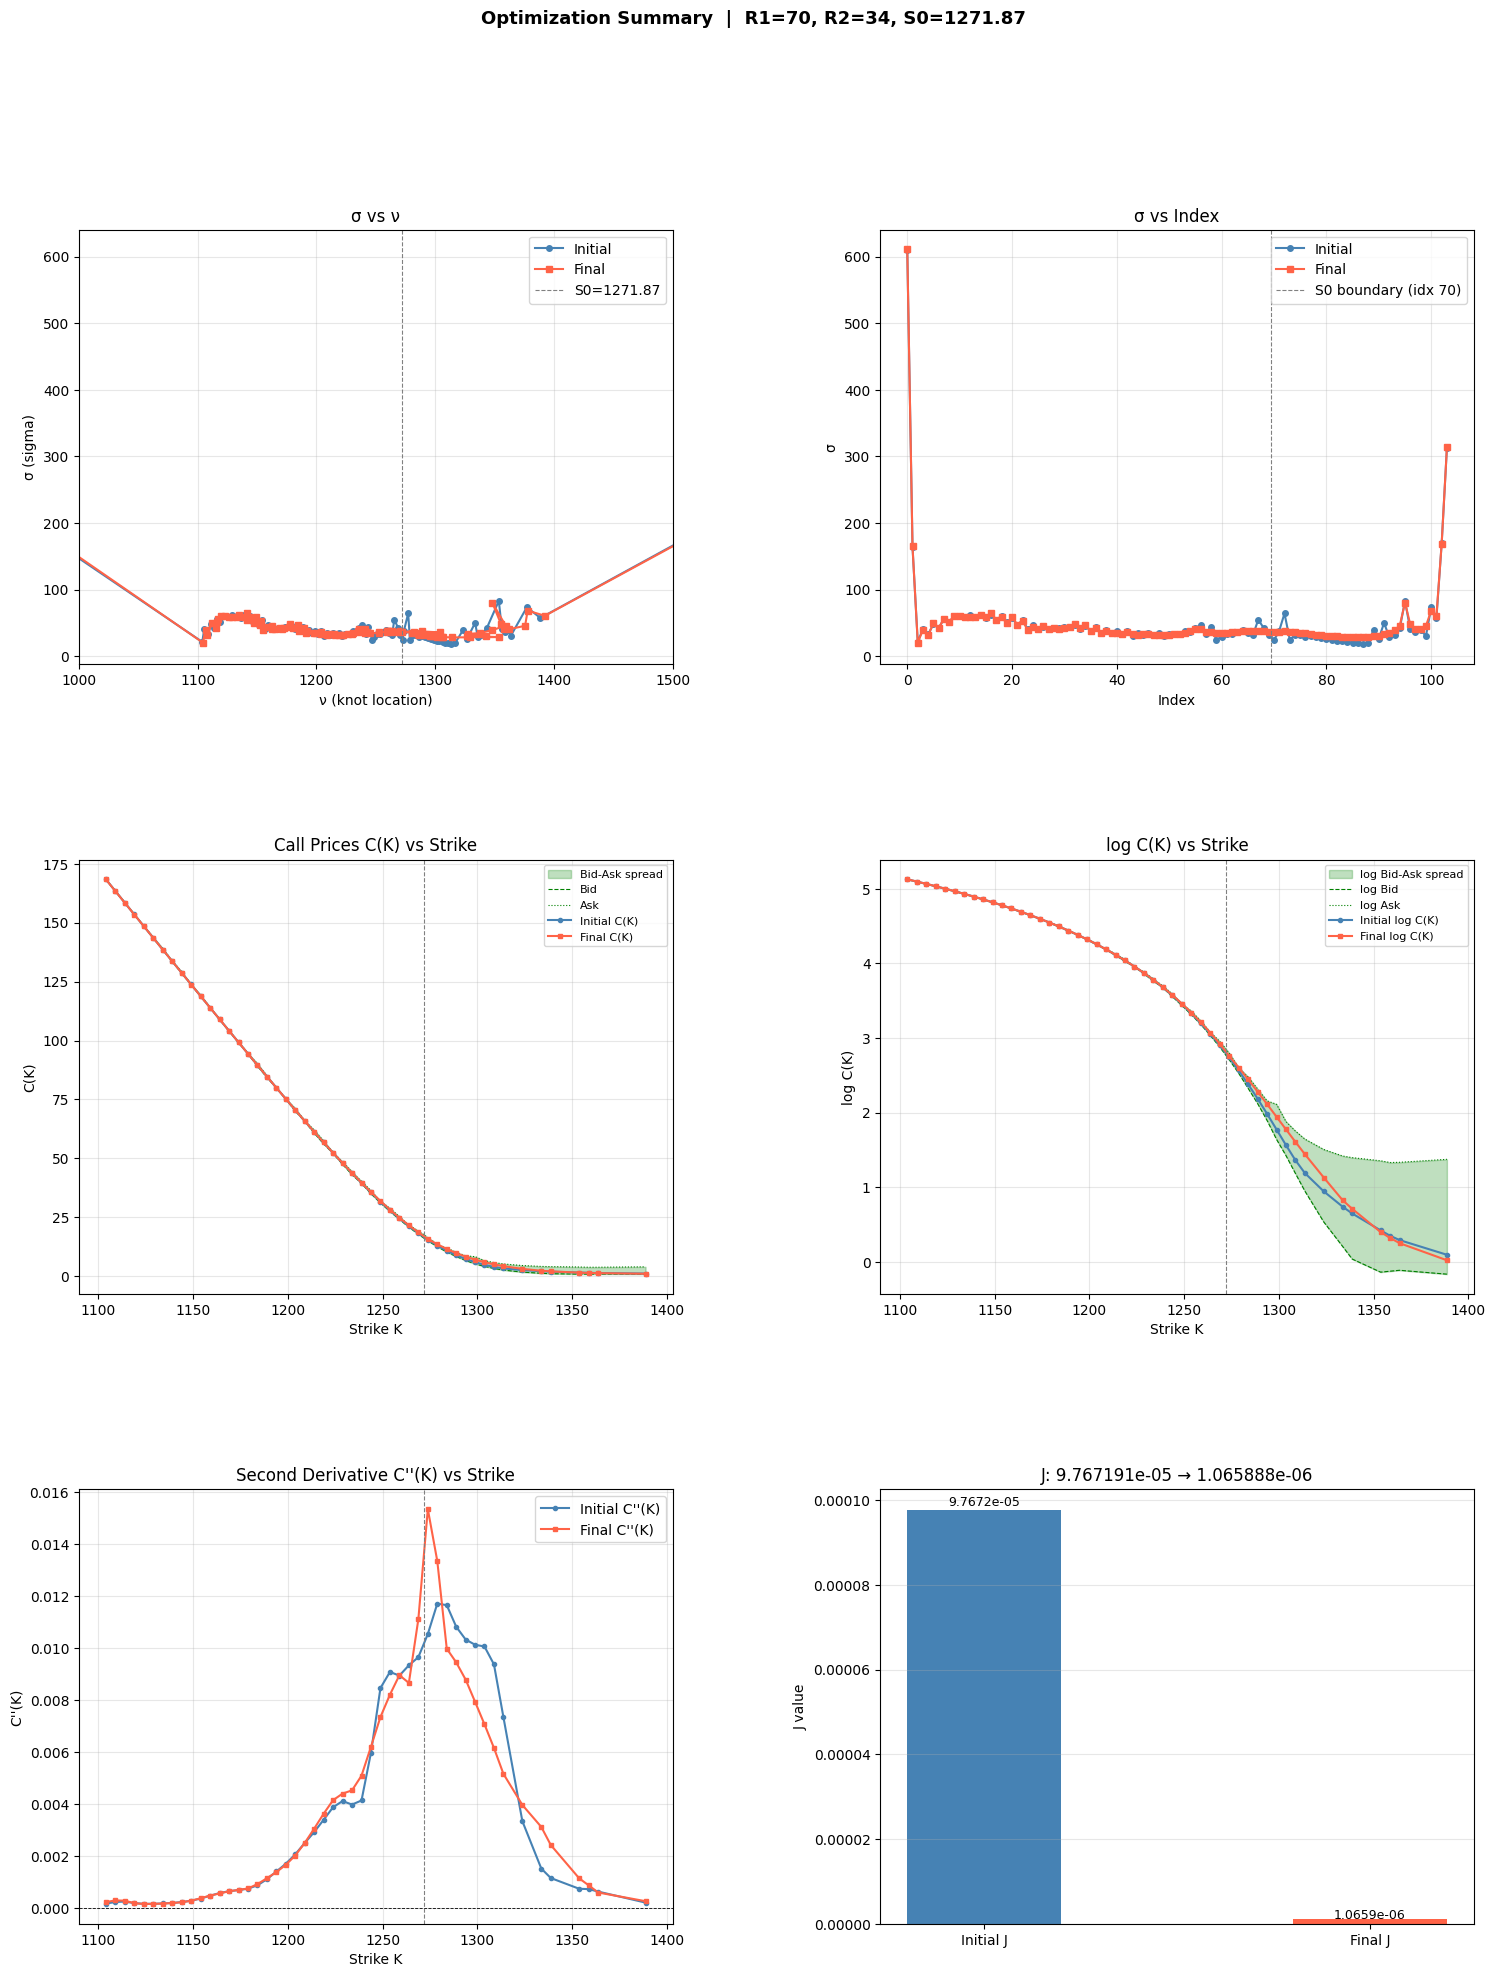


Plot saved to optimization_summary.png


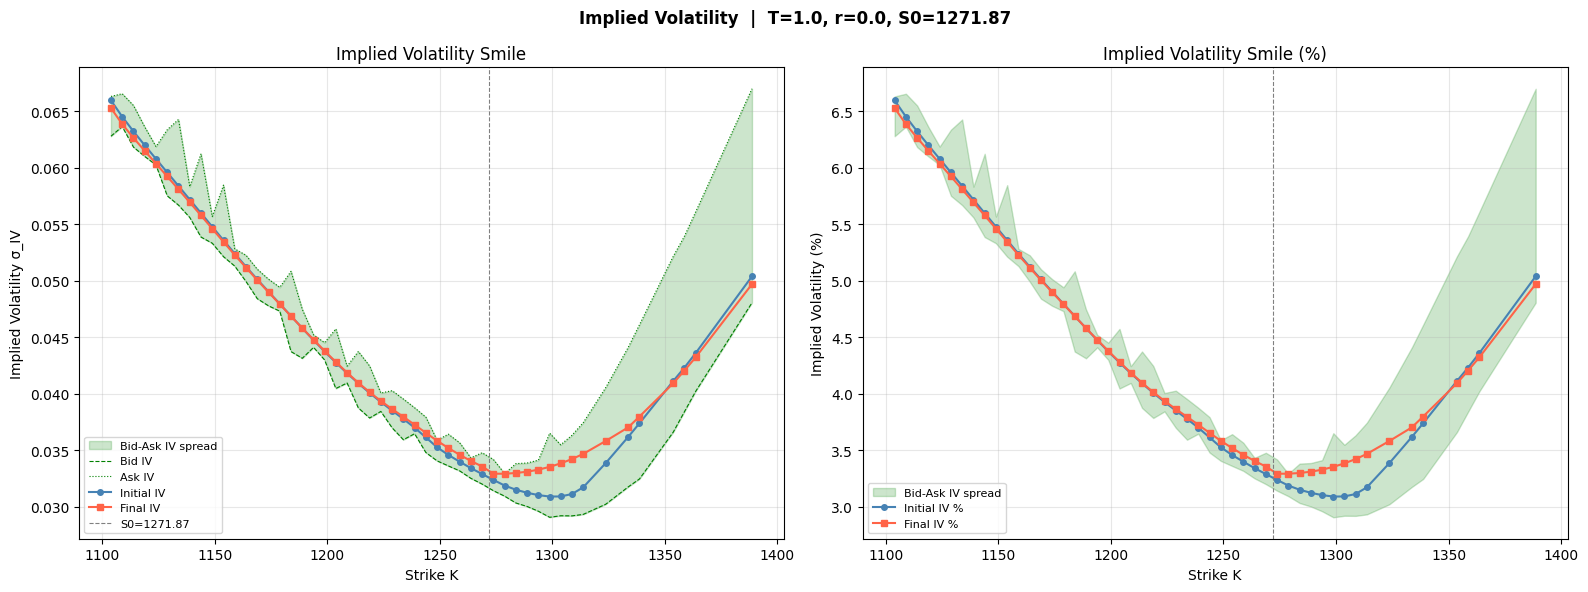

IV plot saved to implied_volatility.png

    Strike    IV_init   IV_final     IV_bid     IV_ask
-------------------------------------------------------
   1103.90      6.60%      6.53%      6.28%      6.63%
   1108.90      6.45%      6.39%      6.36%      6.66%
   1113.90      6.32%      6.27%      6.18%      6.55%
   1118.90      6.20%      6.15%      6.10%      6.36%
   1123.90      6.08%      6.04%      6.02%      6.19%
   1128.90      5.96%      5.92%      5.75%      6.34%
   1133.90      5.84%      5.81%      5.67%      6.43%
   1138.90      5.72%      5.69%      5.56%      5.83%
   1143.90      5.60%      5.58%      5.39%      6.12%
   1148.90      5.48%      5.46%      5.33%      5.57%
   1153.90      5.36%      5.34%      5.21%      5.85%
   1158.90      5.24%      5.23%      5.13%      5.28%
   1163.90      5.13%      5.12%      4.99%      5.23%
   1168.90      5.01%      5.01%      4.84%      5.10%
   1173.90      4.90%      4.90%      4.78%      5.01%
   1178.90      4.80%  

In [33]:
theta_final = run_and_plot(
    R1, R2, S0, sigs1, sigs2, nus1, nus2,
    loss_fn=calculate_J,
    generate_call_prices=generate_call_prices,
    bid_ask=bid_ask,
    rho_init=1.0, rho_scale=5.0, max_outer=100,
    tol_J_change=1e-12, tol_constraint=1e-6,
    max_restarts=50, n_samples=400, search_radius=100.0
)

In [34]:
optimize_augmented_lagrangian(R1, R2, S0, sigs1, sigs2, nus1, nus2, loss_fn=calculate_J, generate_call_prices=generate_call_prices, bid_ask=bid_ask, max_restarts=50)

Phase 0: Neighborhood sampling for best feasible start
  [radius=50.000] feasible: 0/40 | best_J so far: 0.000097671914
  [radius=5.000] feasible: 0/40 | best_J so far: 0.000097671914
  [radius=0.500] feasible: 29/40 | best_J so far: 0.000086943743
  [radius=0.050] feasible: 40/40 | best_J so far: 0.000086943743
  [radius=500.000] feasible: 0/40 | best_J so far: 0.000086943743
  Neighborhood search: improved J from 0.000097671914 to 0.000086943743
Starting from improved seed.


── Outer 01 | rho=1.0000 | restarts=0 | radius=50.00 ──
  J=0.000009463467 | max_viol=6.33e-04 | feasible=False | J_change=inf | stuck=0
  Infeasible → rho → 5.0000

── Outer 02 | rho=5.0000 | restarts=0 | radius=50.00 ──
  ★ New best feasible J: 0.000009463378
  J=0.000009463378 | max_viol=0.00e+00 | feasible=True | J_change=8.94e-11 | stuck=0

── Outer 03 | rho=5.0000 | restarts=0 | radius=50.00 ──
  ★ New best feasible J: 0.000009463378
  J=0.000009463378 | max_viol=0.00e+00 | feasible=True | J_change=6.30e-1

tensor([1.9807e+00, 9.8493e+02, 1.1024e+03, 1.1052e+03, 1.1077e+03, 1.1106e+03,
        1.1140e+03, 1.1162e+03, 1.1186e+03, 1.1212e+03, 1.1242e+03, 1.1264e+03,
        1.1284e+03, 1.1309e+03, 1.1343e+03, 1.1361e+03, 1.1386e+03, 1.1417e+03,
        1.1429e+03, 1.1486e+03, 1.1496e+03, 1.1523e+03, 1.1531e+03, 1.1581e+03,
        1.1586e+03, 1.1628e+03, 1.1640e+03, 1.1674e+03, 1.1683e+03, 1.1705e+03,
        1.1742e+03, 1.1766e+03, 1.1783e+03, 1.1820e+03, 1.1832e+03, 1.1871e+03,
        1.1901e+03, 1.1920e+03, 1.1936e+03, 1.1961e+03, 1.1995e+03, 1.2018e+03,
        1.2041e+03, 1.2070e+03, 1.2089e+03, 1.2123e+03, 1.2120e+03, 1.2167e+03,
        1.2195e+03, 1.2229e+03, 1.2234e+03, 1.2258e+03, 1.2298e+03, 1.2322e+03,
        1.2344e+03, 1.2377e+03, 1.2408e+03, 1.2371e+03, 1.2436e+03, 1.2390e+03,
        1.2471e+03, 1.2526e+03, 1.2523e+03, 1.2593e+03, 1.2620e+03, 1.2612e+03,
        1.2651e+03, 1.2689e+03, 1.2588e+03, 1.2570e+03, 6.0941e+02, 1.6387e+02,
        2.2590e+01, 3.9958e+01, 3.3072e+

# Line Search

In [35]:
# with random search

def line_search_random_test(R1, R2, S0, sigs1, sigs2, nus1, nus2, loss_fn, bid_ask, max_iter, line_search_fn, num_samples=50, neighborhood_radius=0.05, market_strikes=None):

    theta_base = obtain_theta(R1, R2, S0, sigs1, sigs2, nus1, nus2).clone().detach()
    J_best, _, _, _, _, _ = loss_fn(R1, R2, S0, theta_base)
    theta_best = theta_base.clone()

    print(f"Baseline initial J: {J_best.item():.12f}")

    with torch.no_grad():
        for sample_idx in range(num_samples):
            perturbation = (torch.rand_like(theta_base) * 2.0 - 1.0) * neighborhood_radius
            theta_candidate = theta_base + perturbation

            try:
                cand_nus1, cand_nus2 = obtain_nus(R1, R2, theta_candidate)
                cand_sigs1, cand_sigs2 = obtain_sigs(R1, R2, theta_candidate)
                if not check_constraints(R1, R2, S0, cand_sigs1, cand_sigs2, cand_nus1, cand_nus2, bid_ask):
                    continue

                J_candidate, _, _, _, _, _ = loss_fn(R1, R2, S0, theta_candidate)
                if J_candidate < J_best:
                    J_best = J_candidate
                    theta_best = theta_candidate.clone()
                    print(f"  [Sample {sample_idx+1:03d}] New best J found: {J_best.item():.12f}")
            except Exception:
                continue

    print(f"Neighborhood search best J: {J_best.item():.12f}")

    theta_old = theta_best.clone().detach().requires_grad_(True)
    theta_initial = theta_old.clone().detach()

    J_old, _, _, _, _, _ = loss_fn(R1, R2, S0, theta_old)
    market_strikes = bid_ask[:, 0]
    market_bids = bid_ask[:, 1]
    market_asks = bid_ask[:, 2]

    line_search = torch.optim.LBFGS([theta_old], max_iter=max_iter, tolerance_grad=1e-15, tolerance_change=1e-15, line_search_fn=line_search_fn)

    iteration = {"count": 0}

    def closure_bid_ask():
      line_search.zero_grad()

      theta_checkpoint = theta_old.clone().detach()

      with torch.no_grad():
            curr_nus1, curr_nus2 = obtain_nus(R1, R2, theta_old)
            curr_sigs1, curr_sigs2 = obtain_sigs(R1, R2, theta_old)
            is_valid_step = check_constraints(R1, R2, S0, curr_sigs1, curr_sigs2, curr_nus1, curr_nus2, bid_ask, market_strikes)

      if not is_valid_step:
            print("  Invalid step, start bisection line-search")
            alpha = 0.5  # Decay multiplier
            for bisection_iter in range(10): # Up to 10 bisection attempts
                with torch.no_grad():
                    theta_bisected = theta_checkpoint + alpha * (theta_initial - theta_checkpoint)

                    b_nus1, b_nus2 = obtain_nus(R1, R2, theta_bisected)
                    b_sigs1, b_sigs2 = obtain_sigs(R1, R2, theta_bisected)

                    if check_constraints(R1, R2, S0, b_sigs1, b_sigs2, b_nus1, b_nus2, bid_ask, market_strikes):
                        print(f"    Succeeded at bisection step depth {bisection_iter+1} (alpha={alpha})")
                        with torch.no_grad():
                            theta_old.copy_(theta_bisected)
                        is_valid_step = True
                        break
                alpha *= 0.5

            if not is_valid_step:
                print("    Failed to find valid parameters via bisection. Resetting to theta_initial.")
                with torch.no_grad():
                    theta_old.copy_(theta_initial)

      J, _, _, C_K, _, _ = calculate_J(R1, R2, S0, theta_old)
      scaled_J = 1e3*J

      bid_gap = torch.clamp(C_K - market_bids, min=1e-8)
      ask_gap = torch.clamp(market_asks - C_K, min=1e-8)

      # Log barrier
      bid_barrier = -torch.log(bid_gap)
      ask_barrier = -torch.log(ask_gap)
      modified_J = scaled_J + (torch.sum(bid_barrier) + torch.sum(ask_barrier))

      if torch.isnan(modified_J) or torch.isinf(modified_J):
            print("  Mathematical overflow/NaN detected in objective function. Forcing high penalty.")
            modified_J = torch.tensor(1e9, dtype=theta_old.dtype, device=theta_old.device, requires_grad=True)
      else:
            modified_J.backward()

      i = iteration["count"]
      print(f"Iteration {i:02d} | Modified J: {modified_J.item():<14.6f} | J: {J.item():.12f}")

      with torch.no_grad():
          nus1_curr, nus2_curr = obtain_nus(R1, R2, theta_old)
          sigs1_curr, sigs2_curr = obtain_sigs(R1, R2, theta_old)

      print(f"  Left Side:")
      for k in range(R1):
          print(f"   nu{k+1} = {nus1_curr[k].item():11.4f} | sigma{k+1} = {sigs1_curr[k].item():11.4f}")
      print(f"  Right Side:")
      for k in range(R2):
          print(f"   nu{k+1} = {nus2_curr[k].item():11.4f} | sigma{k+1} = {sigs2_curr[k].item():11.4f}")
      print("-" * 60)

      iteration["count"] += 1
      return modified_J

    try:
        line_search.step(closure_bid_ask)
    except Exception as e:
        print(f"Error: {e}\n")

    with torch.no_grad():
        J_optimized, _, _, _, _, _ = loss_fn(R1, R2, S0, theta_old)

        opt_nus1, opt_nus2 = obtain_nus(R1, R2, theta_old)
        opt_sigs1, opt_sigs2 = obtain_sigs(R1, R2, theta_old)

    is_valid = check_constraints(R1, R2, S0, opt_sigs1, opt_sigs2, opt_nus1, opt_nus2, bid_ask, market_strikes)
    print(f"Meeting all constraints: {is_valid}")

    print(f"Initial J Value: {J_old.item():.12f}")
    print(f"Optimized J Value: {J_optimized.item():.12f}\n")

    labels = []
    labels.extend([f"nu1_{i}" for i in range(R1)])
    labels.extend([f"sig1_{i}" for i in range(R1)])
    labels.extend([f"nu2_{i}" for i in range(R2)])
    labels.extend([f"sig2_{i}" for i in range(R2)])

    print(f"{'Parameter':<15} | {'Old Value':<15} | {'Optimized Value':<15}")
    print("-" * 53)

    for i in range(len(theta_old)):
        print(f"{labels[i]:<15} | "
              f"{theta_initial[i].item():<15.6f} | "
              f"{theta_old[i].item():<15.6f}")

    print("-" * 53)
    print(f"Total Penalty Reduction: {((J_old - J_optimized)/J_old * 100).item():.12f}%\n")

In [36]:
def line_search_strict_test(R1, R2, S0, sigs1, sigs2, nus1, nus2, loss_fn, bid_ask, max_iter, line_search_fn=None, num_samples=50, neighborhood_radius=0.05, market_strikes=None):

    # 1. Baseline Setup
    theta_base = obtain_theta(R1, R2, S0, sigs1, sigs2, nus1, nus2).clone().detach()
    market_bids = bid_ask[:, 1]
    market_asks = bid_ask[:, 2]

    # Check if baseline is valid
    base_nus1, base_nus2 = obtain_nus(R1, R2, theta_base)
    base_sigs1, base_sigs2 = obtain_sigs(R1, R2, theta_base)
    base_valid = check_constraints(R1, R2, S0, base_sigs1, base_sigs2, base_nus1, base_nus2, bid_ask, market_strikes)

    # 2. History Tracking for Strict Fallbacks
    # We maintain a reference to the absolute best VALID parameter set seen so far
    best_valid_state = {
        "theta": theta_base.clone() if base_valid else None,
        "J": loss_fn(R1, R2, S0, theta_base)[0].item() if base_valid else float('inf')
    }

    # 3. Neighborhood Search (Strictly looking for valid alternatives)
    with torch.no_grad():
        for sample_idx in range(num_samples):
            perturbation = (torch.rand_like(theta_base) * 2.0 - 1.0) * neighborhood_radius
            theta_candidate = theta_base + perturbation

            try:
                cand_nus1, cand_nus2 = obtain_nus(R1, R2, theta_candidate)
                cand_sigs1, cand_sigs2 = obtain_sigs(R1, R2, theta_candidate)

                if check_constraints(R1, R2, S0, cand_sigs1, cand_sigs2, cand_nus1, cand_nus2, bid_ask, market_strikes):
                    J_candidate, _, _, _, _ = loss_fn(R1, R2, S0, theta_candidate)
                    if J_candidate < best_valid_state["J"]:
                        best_valid_state["J"] = J_candidate
                        best_valid_state["theta"] = theta_candidate.clone()
                        print(f"  [Sample {sample_idx+1:03d}] Safe valid seed J found: {best_valid_state['J']:.12f}")
            except Exception:
                continue

    # Fail-safe check: If neither base nor random search is valid, we must warn the user
    if best_valid_state["theta"] is None:
        print(" CRITICAL: Initial parameters and all neighborhood mutations violate market spreads!")
        print("Switching temporarily to the base parameters to let gradients push them inside.")
        theta_start = theta_base
    else:
        print(f"Starting L-BFGS from best valid state. J: {best_valid_state['J']:.12f}\n")
        theta_start = best_valid_state["theta"]

    theta_old = theta_start.clone().detach().requires_grad_(True)
    theta_initial = theta_old.clone().detach()
    J_old, _, _, _, _ = loss_fn(R1, R2, S0, theta_old)

    line_search = torch.optim.LBFGS([theta_old], max_iter=max_iter, tolerance_grad=1e-15, tolerance_change=1e-15, line_search_fn=line_search_fn)
    iteration = {"count": 0}

    # 4. Optimization Closure Loop
    def closure_bid_ask():
        line_search.zero_grad()

        with torch.no_grad():
          theta_old.clamp_(min=-10.0, max=5000.0)

        J, _, _, _, _ = loss_fn(R1, R2, S0, theta_old)
        scaled_J = 1e3 * J

        C_K_pred = generate_call_prices(market_strikes, R1, R2, S0, theta_old, c_v1, c_v2)

        # Differentiable Violations
        bid_violations = torch.clamp(market_bids - C_K_pred, min=0.0)
        ask_violations = torch.clamp(C_K_pred - market_asks, min=0.0)

        # Dynamic History Logging
        with torch.no_grad():
            c_nus1, c_nus2 = obtain_nus(R1, R2, theta_old)
            c_sigs1, c_sigs2 = obtain_sigs(R1, R2, theta_old)
            if check_constraints(R1, R2, S0, c_sigs1, c_sigs2, c_nus1, c_nus2, bid_ask, market_strikes):
                if J.item() < best_valid_state["J"]:
                    best_valid_state["J"] = J.item()
                    best_valid_state["theta"] = theta_old.clone().detach()

        # Numeric protections for logs
        bid_gap = torch.clamp(C_K_pred - market_bids, min=1e-8)
        ask_gap = torch.clamp(market_asks - C_K_pred, min=1e-8)

        # Soft Penalty Wall (1e7 multiplier heavily suppresses violations)
        violation_penalty = 1 * (torch.sum(bid_violations**2) + torch.sum(ask_violations**2))
        modified_J = scaled_J + torch.sum(-torch.log(bid_gap)) + torch.sum(-torch.log(ask_gap)) + violation_penalty

        if torch.isnan(modified_J) or torch.isinf(modified_J):
            modified_J = torch.tensor(1e9, dtype=theta_old.dtype, device=theta_old.device, requires_grad=True)
        else:
            modified_J.backward()

        print(f"Iteration {iteration['count']:02d} | Modified J: {modified_J.item():<14.6f} | J: {J.item():.12f} | Violation Penalty: {violation_penalty.item():.4f}")
        iteration["count"] += 1
        return modified_J

    # 5. Run L-BFGS
    try:
        line_search.step(closure_bid_ask)
    except Exception as e:
        print(f"Optimizer breakdown intercepted: {e}")

    # 6. STRICT ENFORCEMENT POST-FILTER
    # After optimization completes, check if the final state matches constraints.
    with torch.no_grad():
        final_nus1, final_nus2 = obtain_nus(R1, R2, theta_old)
        final_sigs1, final_sigs2 = obtain_sigs(R1, R2, theta_old)

    if not check_constraints(R1, R2, S0, final_sigs1, final_sigs2, final_nus1, final_nus2, bid_ask, market_strikes):
        print("\n Final L-BFGS iteration ended outside constraints!")
        if best_valid_state["theta"] is not None:
            print(">>> Reverting parameters to the absolute best valid historical state found.")
            with torch.no_grad():
                theta_old.copy_(best_valid_state["theta"])
        else:
            print(">>> No valid historical state was recorded. Keeping current values.")

    # 7. Final Outputs
    with torch.no_grad():
        J_optimized, _, _, _, _ = loss_fn(R1, R2, S0, theta_old)
        opt_nus1, opt_nus2 = obtain_nus(R1, R2, theta_old)
        opt_sigs1, opt_sigs2 = obtain_sigs(R1, R2, theta_old)

    is_valid = check_constraints(R1, R2, S0, opt_sigs1, opt_sigs2, opt_nus1, opt_nus2, bid_ask, market_strikes)
    print(f"\nMeeting all constraints strictly: {is_valid}")
    print(f"Optimized Tracking J Value: {J_optimized.item():.12f}")

    return theta_old

In [37]:
# without random search

# def line_search_test(R1, R2, S0, sigs1, sigs2, nus1, nus2, loss_fn, bid_ask, max_iter, line_search_fn):
#     theta_old = obtain_theta(R1, R2, S0, sigs1, sigs2, nus1, nus2)
#     theta_old = theta_old.clone().detach().requires_grad_(True)
#     theta_initial = theta_old.clone().detach()

#     J_old, _, _, _ = loss_fn(R1, R2, S0, theta_old)
#     market_strikes = bid_ask[:, 0]
#     market_bids = bid_ask[:, 1]
#     market_asks = bid_ask[:, 2]

#     line_search = torch.optim.LBFGS([theta_old], max_iter=max_iter, tolerance_grad=1e-15, tolerance_change=1e-15, line_search_fn=line_search_fn)

#     iteration = {"count": 0}

#     def closure_bid_ask():
#       line_search.zero_grad()

#       J, _, _, C_K = calculate_J(R1, R2, S0, theta_old)
#       scaled_J = 1e3*J

#       bid_gap = torch.clamp(C_K - market_bids, min=1e-8)
#       ask_gap = torch.clamp(market_asks - C_K, min=1e-8)

#       # Log barrier
#       bid_barrier = -torch.log(bid_gap)
#       ask_barrier = -torch.log(ask_gap)
#       modified_J = scaled_J + (torch.sum(bid_barrier) + torch.sum(ask_barrier))

#       modified_J.backward()

#       i = iteration["count"]
#       print(f"Iteration {i:02d} | Modified J: {modified_J.item():<14.6f} | J: {J.item():.12f}")

#       with torch.no_grad():
#           nus1_curr, nus2_curr = obtain_nus(R1, R2, theta_old)
#           sigs1_curr, sigs2_curr = obtain_sigs(R1, R2, theta_old)

#       print(f"  Left Side:")
#       for k in range(R1):
#           print(f"   nu{k+1} = {nus1_curr[k].item():11.4f} | sigma{k+1} = {sigs1_curr[k].item():11.4f}")
#       print(f"  Right Side:")
#       for k in range(R2):
#           print(f"   nu{k+1} = {nus2_curr[k].item():11.4f} | sigma{k+1} = {sigs2_curr[k].item():11.4f}")
#       print("-" * 60)

#       iteration["count"] += 1
#       return modified_J

#     try:
#         line_search.step(closure_bid_ask)
#     except Exception as e:
#         print(f"Error: {e}\n")

#     with torch.no_grad():
#         J_optimized, _, _, final_prices = loss_fn(R1, R2, S0, theta_old)

#         opt_nus1, opt_nus2 = obtain_nus(R1, R2, theta_old)
#         opt_sigs1, opt_sigs2 = obtain_sigs(R1, R2, theta_old)

#     is_valid = check_constraints(R1, R2, S0, opt_sigs1, opt_sigs2, opt_nus1, opt_nus2, bid_ask)
#     print(f"Meeting all constraints: {is_valid}")

#     print(f"Initial J Value: {J_old.item():.12f}")
#     print(f"Optimized J Value: {J_optimized.item():.12f}\n")

#     labels = []
#     labels.extend([f"nu1_{i}" for i in range(R1)])
#     labels.extend([f"sig1_{i}" for i in range(R1)])
#     labels.extend([f"nu2_{i}" for i in range(R2)])
#     labels.extend([f"sig2_{i}" for i in range(R2)])

#     print(f"{'Parameter':<15} | {'Old Value':<15} | {'Optimized Value':<15}")
#     print("-" * 53)

#     for i in range(len(theta_old)):
#         print(f"{labels[i]:<15} | "
#               f"{theta_initial[i].item():<15.6f} | "
#               f"{theta_old[i].item():<15.6f}")

#     print("-" * 53)
#     print(f"Total Penalty Reduction: {((J_old - J_optimized)/J_old * 100).item():.12f}%\n")

In [38]:
line_search_strict_test(R1, R2, S0, sigs1, sigs2, nus1, nus2, calculate_J, bid_ask, max_iter=200, line_search_fn=None, market_strikes=bid_ask[:, 0])

  [Sample 001] Safe valid seed J found: 0.000097610350
  [Sample 002] Safe valid seed J found: 0.000097339491
  [Sample 003] Safe valid seed J found: 0.000097324180
  [Sample 013] Safe valid seed J found: 0.000097232914
  [Sample 025] Safe valid seed J found: 0.000097232506
  [Sample 040] Safe valid seed J found: 0.000097091594
  [Sample 046] Safe valid seed J found: 0.000097080510
Starting L-BFGS from best valid state. J: 0.000097080510

Optimizer breakdown intercepted: name 'c_v1' is not defined

Meeting all constraints strictly: True
Optimized Tracking J Value: 0.000097080510


tensor([2.7024e-02, 9.8586e+02, 1.1039e+03, 1.1056e+03, 1.1089e+03, 1.1110e+03,
        1.1139e+03, 1.1161e+03, 1.1189e+03, 1.1212e+03, 1.1239e+03, 1.1264e+03,
        1.1289e+03, 1.1315e+03, 1.1339e+03, 1.1365e+03, 1.1389e+03, 1.1416e+03,
        1.1439e+03, 1.1466e+03, 1.1489e+03, 1.1517e+03, 1.1539e+03, 1.1568e+03,
        1.1589e+03, 1.1616e+03, 1.1639e+03, 1.1665e+03, 1.1689e+03, 1.1715e+03,
        1.1739e+03, 1.1765e+03, 1.1789e+03, 1.1816e+03, 1.1839e+03, 1.1867e+03,
        1.1889e+03, 1.1918e+03, 1.1939e+03, 1.1965e+03, 1.1988e+03, 1.2016e+03,
        1.2038e+03, 1.2066e+03, 1.2088e+03, 1.2114e+03, 1.2138e+03, 1.2165e+03,
        1.2188e+03, 1.2215e+03, 1.2238e+03, 1.2264e+03, 1.2288e+03, 1.2312e+03,
        1.2338e+03, 1.2362e+03, 1.2388e+03, 1.2418e+03, 1.2438e+03, 1.2470e+03,
        1.2488e+03, 1.2512e+03, 1.2538e+03, 1.2562e+03, 1.2588e+03, 1.2615e+03,
        1.2638e+03, 1.2657e+03, 1.2688e+03, 1.2706e+03, 6.1048e+02, 1.6403e+02,
        2.1437e+01, 4.1084e+01, 3.2546e+

## Test 1

In [39]:
R1, R2 = 4, 3
S0 = 1271.87

sigs1 = torch.tensor([149.0, 130.0, 250.0, 160.0])
sigs2 = torch.tensor([155.0, 180.0, 210.0])
nus1 = torch.linspace(800, 1200, R1)
nus2 = torch.linspace(1400, 2200, R2)
theta = obtain_theta(R1, R2, S0, sigs1, sigs2, nus1, nus2)

initial_prices = C_K(R1, R2, S0, theta)

eps_bid_vector = torch.clamp(initial_prices * 0.025, min=0.50)
eps_ask_vector = torch.clamp(initial_prices * 0.025, min=0.50)

bid_ask = generate_bid_ask_matrix(R1, R2, S0, theta, eps_bid_vector, eps_ask_vector)

# line_search_test(R1, R2, S0, sigs1, sigs2, nus1, nus2, calculate_J, bid_ask, max_iter=200, line_search_fn="strong_wolfe")
line_search_random_test(R1, R2, S0, sigs1, sigs2, nus1, nus2, calculate_J, bid_ask, max_iter=200, line_search_fn="strong_wolfe")
print(initial_prices)

TypeError: C_K() missing 3 required positional arguments: 'theta', 'c_v1', and 'c_v2'

## Test 2

In [ ]:
R1, R2 = 20, 20
S0 = 1400

# sigs1 = torch.randint(100, 300, (20,))
# sigs2 = torch.randint(100, 300, (20,))
sigs1 = torch.repeat_interleave(torch.tensor([100.0, 150.0, 200.0, 250.0], dtype=torch.float64), repeats=5)
sigs2 = torch.repeat_interleave(torch.tensor([100.0, 150.0, 200.0, 250.0], dtype=torch.float64), repeats=5)
nus1 = torch.linspace(700, 1350, R1)
nus2 = torch.linspace(1450, 2300, R2)
theta = obtain_theta(R1, R2, S0, sigs1, sigs2, nus1, nus2)

initial_prices = C_K(R1, R2, S0, theta)

eps_bid_vector = torch.clamp(initial_prices * 0.025, min=0.50)
eps_ask_vector = torch.clamp(initial_prices * 0.025, min=0.50)

bid_ask = generate_bid_ask_matrix(R1, R2, S0, theta, eps_bid_vector, eps_ask_vector)

line_search_test(R1, R2, S0, sigs1, sigs2, nus1, nus2, calculate_J, bid_ask, max_iter=30, line_search_fn="strong_wolfe")

## Test 3

In [ ]:
R1, R2 = 70, 50
S0 = 1730

# sigs1 = torch.randint(500, 700, (70,))
# sigs2 = torch.randint(500, 700, (50,))
sigs1 = torch.repeat_interleave(torch.tensor([100.0, 150.0, 200.0, 250.0, 300.0], dtype=torch.float64), repeats=14)
sigs2 = torch.repeat_interleave(torch.tensor([100.0, 150.0, 200.0, 250.0, 300.0], dtype=torch.float64), repeats=10)
nus1 = torch.linspace(600, 1700, R1)
nus2 = torch.linspace(1750, 3120, R2)
theta = obtain_theta(R1, R2, S0, sigs1, sigs2, nus1, nus2)

initial_prices = C_K(R1, R2, S0, theta)

eps_bid_vector = torch.clamp(initial_prices * 0.025, min=0.50)
eps_ask_vector = torch.clamp(initial_prices * 0.025, min=0.50)

bid_ask = generate_bid_ask_matrix(R1, R2, S0, theta, eps_bid_vector, eps_ask_vector)

line_search_test(R1, R2, S0, sigs1, sigs2, nus1, nus2, calculate_J, bid_ask, max_iter=30, line_search_fn="strong_wolfe")

## Test 4

In [ ]:
R1, R2 = 4, 3
S0 = 1271.87

sigs1 = torch.tensor([149.0, 130.0, 250.0, 160.0])
sigs2 = torch.tensor([155.0, 180.0, 210.0])
nus1 = torch.linspace(800, 1200, R1)
nus2 = torch.linspace(1400, 2200, R2)
theta = obtain_theta(R1, R2, S0, sigs1, sigs2, nus1, nus2)

initial_prices = C_K(R1, R2, S0, theta)

eps_bid_vector = torch.tensor([0.5, 0.1, 0.1, 0.2, 0.3, 0.4, 0.35, 0.2])
eps_ask_vector = torch.tensor([0.6, 0.3, 0.2, 0.1, 0.2, 0.1, 0.3, 0.24])

bid_ask = generate_bid_ask_matrix(R1, R2, S0, theta, eps_bid_vector, eps_ask_vector)

line_search_test(R1, R2, S0, sigs1, sigs2, nus1, nus2, calculate_J, bid_ask, max_iter=30, line_search_fn="strong_wolfe")

## Test 5

In [ ]:
R1, R2 = 4, 3
S0 = 1271.87

sigs1 = torch.tensor([149.0, 130.0, 250.0, 160.0])
sigs2 = torch.tensor([155.0, 180.0, 210.0])
nus1 = torch.linspace(800, 1200, R1)
nus2 = torch.linspace(1400, 2200, R2)
theta = obtain_theta(R1, R2, S0, sigs1, sigs2, nus1, nus2)

initial_prices = C_K(R1, R2, S0, theta)

eps_bid_vector = torch.tensor([1, 2, 4, 5, 3, 2, 1, 3])
eps_ask_vector = torch.tensor([1, 2, 4, 5, 3, 2, 1, 3])

bid_ask = generate_bid_ask_matrix(R1, R2, S0, theta, eps_bid_vector, eps_ask_vector)

line_search_test(R1, R2, S0, sigs1, sigs2, nus1, nus2, calculate_J, bid_ask, max_iter=30, line_search_fn="strong_wolfe")

## Test with csv file

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

S0 = 1271.87

arb = pd.read_csv(
    "ArbFree_calls_strikes.csv",
    header = None,
    names = ["C", "K"]
)

arb = arb.sort_values("K").reset_index(drop=True)

K = arb["K"].to_numpy(dtype=float)
C = arb["C"].to_numpy(dtype=float)

intrinsic = np.maximum(S0 - K, 0.0)
V = C - intrinsic

arb["intrinsic"] = intrinsic
arb["V"] = V

plt.figure(figsize=(10, 5))

plt.plot(K, V, marker="o", linewidth=1.5, color="blue", label="V(K) = C(K) - intrinsic")

plt.axvline(S0, color="black", linestyle=":", linewidth=1, label="S0")
plt.axhline(0, color="gray", linewidth=1)

plt.xlabel("K")
plt.ylabel("time value V(K)")
plt.title("Time value from arb-free call prices")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

# Bisection Line Search

In [ ]:
def bisection_line_search(theta, gradient, loss_fn, R1, R2, S0, alpha_max=10, tol=1e-5, max_iter=20):

    alpha_left = 0
    alpha_right = alpha_max

    best_theta = theta.clone().detach()
    best_loss = float('inf')
    best_alpha = 0

    for iteration in range(max_iter):
        alpha_mid = (alpha_left + alpha_right)/2

        new_theta = theta - alpha_mid * gradient
        new_param = new_theta.clone().detach().requires_grad_(True)

        J_candidate, _, _ = loss_fn(R1, R2, S0, new_param)
        scaled_J = J_candidate * 1e7
        scaled_J.backward()

        # p = grad(theta_mid) (dot product) (initial_gradient)
        curr_grad = new_param.grad.clone().detach()
        p = torch.sum(- curr_grad * gradient).item()

        if J_candidate.item() < best_loss:
            best_loss = J_candidate.item()
            best_theta = new_theta.clone().detach()
            best_alpha = alpha_mid

        if (alpha_right - alpha_left) < tol:
            break

        if p > 0:
            # > min, move right bound inward
            alpha_right = alpha_mid
        else:
            alpha_left = alpha_mid

    return best_theta, best_alpha, best_loss

In [ ]:
def bisection_line_search_test(R1, R2, S0, theta, iter, max_iter, alpha_max):
  for i in range(iter):
    J, _, _, _, _, _ = calculate_J(R1, R2, S0, theta)
    scaled_J = J * 1e7
    scaled_J.backward()

    init_gradient = theta.grad.clone().detach()
    theta.grad.zero_()

    theta_new, alpha, curr_loss = bisection_line_search(theta=theta, gradient=init_gradient, loss_fn=calculate_J, R1=R1, R2=R2, S0=S0,
                                                        alpha_max=alpha_max, tol=1e-6, max_iter=max_iter)

    print(f"Iteration {i:02d} | Alpha: {alpha:<9.6f} | Current J: {curr_loss:.12f}")

    with torch.no_grad():
        theta.copy_(theta_new)
        idx = 0
        nus1 = theta[idx : idx + R1]; idx += R1
        sigs1_raw_curr = theta[idx : idx + R1]; idx += R1
        nus2 = theta[idx : idx + R2]; idx += R2
        sigs2_raw_curr = theta[idx : idx + R2]; idx += R2

        sigs1 = torch.nn.functional.softplus(sigs1_raw_curr) + 1e-6
        sigs2 = torch.nn.functional.softplus(sigs2_raw_curr) + 1e-6

    print(f"  Left Side:")
    for i in range(R1):
        print(f"   nu{i+1} = {nus1[i].item():11.4f} | sigma{i+1} = {sigs1[i].item():11.4f}")

    print(f"  Right Side:")
    for i in range(R2):
        print(f"   nu{i+1} = {nus2[i].item():11.4f} | sigma{i+1} = {sigs2[i].item():11.4f}")

    print("-" * 60)

In [ ]:
def bisection_line_search_test(R1, R2, S0, theta, iter, max_iter, alpha_max):
  for i in range(iter):
    J, _, _, _, _, _ = calculate_J(R1, R2, S0, theta)
    scaled_J = J * 1e7
    scaled_J.backward()

    init_gradient = theta.grad.clone().detach()
    theta.grad.zero_()

    theta_new, alpha, curr_loss = bisection_line_search(theta=theta, gradient=init_gradient, loss_fn=calculate_J, R1=R1, R2=R2, S0=S0,
                                                        alpha_max=alpha_max, tol=1e-6, max_iter=max_iter)

    print(f"Iteration {i:02d} | Alpha: {alpha:<9.6f} | Current J: {curr_loss:.12f}")

    with torch.no_grad():
        theta.copy_(theta_new)
        idx = 0
        nus1 = theta[idx : idx + R1]; idx += R1
        sigs1_raw_curr = theta[idx : idx + R1]; idx += R1
        nus2 = theta[idx : idx + R2]; idx += R2
        sigs2_raw_curr = theta[idx : idx + R2]; idx += R2

        sigs1 = torch.nn.functional.softplus(sigs1_raw_curr) + 1e-6
        sigs2 = torch.nn.functional.softplus(sigs2_raw_curr) + 1e-6

    print(f"  Left Side:")
    for i in range(R1):
        print(f"   nu{i+1} = {nus1[i].item():11.4f} | sigma{i+1} = {sigs1[i].item():11.4f}")

    print(f"  Right Side:")
    for i in range(R2):
        print(f"   nu{i+1} = {nus2[i].item():11.4f} | sigma{i+1} = {sigs2[i].item():11.4f}")

    print("-" * 60)